# Предиктор исходов теннисных матчей РТТ

Задача: обучить модель, которая по истории матчей, рейтинговым данным и признакам соперничества оценивает вероятность победы одного игрока над другим.

Ключевая методологическая идея: модель обучается в perspective-формате — каждый матч представлен двумя строками, с точки зрения каждого игрока. Для практического прогноза по паре игроков итоговая вероятность рассчитывается на уровне матча через симметризацию двух прогнозов: `A vs B` и `B vs A`.

In [1]:
!pip install -q catboost openpyxl


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Импорты и настройки

In [2]:
from __future__ import annotations

from collections import defaultdict
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from catboost import CatBoostClassifier, Pool
from IPython.display import display, Markdown

from sklearn.calibration import calibration_curve
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    log_loss,
    roc_auc_score,
    roc_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


# ---------------------------------------------------------------------
# Основные настройки проекта
# ---------------------------------------------------------------------

DATA_PATH = Path(r"assembled_predictor\predictor_model_dataset_from_parsers.xlsx")
SHEET_NAME = "ml_dataset"

# Временное разделение: train строго до даты, test начиная с даты.
SPLIT_DATE = pd.Timestamp("2025-12-22")

# Внутренняя validation-часть внутри train-периода.
# Используется только для выбора best_iteration CatBoost и шкалы rating_only.
DEV_VALID_FRACTION = 0.20

# Воспроизводимость обучения и SHAP sampling.
RANDOM_SEED = 23

# Окна, которые реально используются финальной моделью.
SCHEDULE_STRENGTH_WINDOW = 10       #за сколько последних матчей рассчитываем средний ELO соперников игрока
                                    #насколько сложным был календарь игрока в целом за последние 10 матчей
OPP_ELO_LAST_WINDOW = 5             #за сколько последних матчей рассчитываем средний ELO соперников игрока
                                    #насколько сильными были самые последние соперники игрока

# Параметры ELO:
ELO_BASE_RATING = 1500.0            #cтартовый рейтинг игрока
ELO_K = 24.0                        #базовая скорость изменения ELO после матча
                                    #чем выше K, тем сильнее рейтинг меняется после каждой победы/поражения
ELO_MARGIN_COEF = 0.30              #коэффициент учета уверенности победы через разницу в геймах
                                    #насколько сильно разница в геймах увеличивает изменение ELO
ELO_RECENCY_HALF_LIFE_DAYS = 90.0   #насколько сильно обновляется ELO после паузы между матчами
                                    #если игрок давно не играл, новый матч получает больший вес, потому что старая оценка силы могла устареть


# Параметры common-opponents фичей.
COMMON_OPP_HALF_LIFE_DAYS = 180.0   #параметр давности для признаков общих соперников
                                    #чем свежее матчи против общих соперников, тем больший вес они имеют
                                    #показывает горизонт, на котором влияние старого результата уже заметно снижается, но не исчезает полностью


# CatBoost: три режима обучения финальной модели.
# Выбор режима выполняется автоматически по внутренней validation-выборке.
#
# Логика выбора:
# 1) считаем validation LogLoss для каждого режима;
# 2) находим лучший validation LogLoss;
# 3) если несколько режимов находятся в пределах MODEL_SELECTION_VALID_TOLERANCE
#    от лучшего результата, выбираем вариант с меньшим train-valid gap;
# 4) при равенстве выбираем более простой режим.
#
# Это позволяет не переусложнять модель, если более тяжелый режим не дает
# содержательного прироста на validation.

MODEL_SELECTION_VALID_TOLERANCE = 0.0025        #порог, при котором результаты разных режимов по метрике LogLoss считаются практически сопоставимыми,
                                                #что приводит к выбору режима с меньшим разрывом между train и validation

CATBOOST_COMMON_PARAMS = dict(
    loss_function="Logloss",            #функция потерь для обучения бинарной классификации,LogLoss, т.к. она штрафует не только неправильный класс, но и плохую оценку вероятности
    eval_metric="Logloss",              #метрика для контроля качества на validation-выборке (та же метрика, что и в обучении, чтобы выбирать модель именно по качеству вероятностного прогноза)
    random_seed=RANDOM_SEED,
    verbose=False,                      #отключаем подробный лог обучения, чтобы не загромождать ноутбук
    thread_count=1,                     #обучаем в один поток - медленнее, но лучше воспроизводимость результатов
    od_type="Iter",                     #включаем early stopping по числу итераций:
                                        #если качество на validation перестает улучшаться в течение заданного числа итераций (od_wait, см. ниже), обучение останавливается
                                        #это помогает не переобучать модель
)

CATBOOST_TRAINING_MODES = {
    "light": {
        **CATBOOST_COMMON_PARAMS,
        "iterations": 1200,             #максимальное число деревьев
        "learning_rate": 0.03,          #скорость обучения, при высоком значении модели нужно меньше деревьев
        "depth": 6,                     #глубина деревьев, при умеренной сложности модель может ловить нелинейности, но не становится слишком тяжелой 
        "l2_leaf_reg": 5.0,             #L2-регуляризация листьев дерева, помогает снизить вероятность переобучения
        "od_wait": 150,                 #Early stopping: если validation LogLoss не улучшается 150 итераций, обучение останавливается
        "complexity_rank": 1,
        "description": "Быстрый режим: компактная модель для контрольного запуска.",
    },
    "balanced": {
        **CATBOOST_COMMON_PARAMS,
        "iterations": 3500,
        "learning_rate": 0.018,
        "depth": 6,
        "l2_leaf_reg": 8.0,
        "od_wait": 300,
        "complexity_rank": 2,
        "description": "Сбалансированный режим: больше деревьев и ниже learning rate.",
    },
    "power": {
        **CATBOOST_COMMON_PARAMS,
        "iterations": 6000,
        "learning_rate": 0.012,
        "depth": 7,
        "l2_leaf_reg": 10.0,
        "od_wait": 400,
        "complexity_rank": 3,
        "description": "Мощный режим: более глубокие деревья и больше итераций.",
    },
}


# Дополнительные основные модели для сравнения с CatBoost.
# Они обучаются на том же полном наборе признаков, что и CatBoost.
GBM_PARAMS = dict(
    n_estimators=700,               #число деревьев в градиентном бустинге
    learning_rate=0.025,            #скорость обучения; ниже скорость — плавнее обучение
    max_depth=3,                    #деревья в sklearn GBM обычно делают неглубокими
    min_samples_leaf=10,            #минимальный размер листа для снижения переобучения
    subsample=0.85,                 #стохастический бустинг: каждое дерево видит часть строк
    random_state=RANDOM_SEED,
)

RANDOM_FOREST_PARAMS = dict(
    n_estimators=700,               #число деревьев случайного леса
    max_depth=None,                 #глубину не ограничиваем жестко, но ограничиваем листья ниже
    min_samples_leaf=5,             #защита от слишком мелких листьев и переобучения
    max_features="sqrt",            #каждое дерево/разбиение использует подмножество признаков
    class_weight="balanced_subsample",
    n_jobs=-1,                      #используем доступные ядра процессора
    random_state=RANDOM_SEED,
)

#сетки параметров для перевода рейтинговой разницы в вероятность победы в простых benchmark-моделях
RATING_SCALE_GRID = np.array([50, 75, 100, 125, 150, 175, 200, 250, 300, 400], dtype=float)
ADJUSTED_RATING_SCALE_GRID = np.array([10, 15, 20, 25, 30, 40, 50, 75, 100, 125, 150, 200, 250], dtype=float)
RELATIVE_RATING_SCALE_GRID = np.array([25, 50, 75, 100, 150, 200, 250, 300, 400, 500, 750, 1000], dtype=float)

## Расчет ELO в модели

ELO — это внутренний динамический рейтинг силы игрока, рассчитанный по истории матчей.  
В базовой версии ожидаемая вероятность победы игрока A над игроком B считается так:

$$
P(A) = \frac{1}{1 + 10^{(R_B - R_A)/400}}
$$

где:

- $R_A$ — ELO игрока A до матча;
- $R_B$ — ELO игрока B до матча;
- $P(A)$ — ожидаемая вероятность победы игрока A.

Если $R_A = R_B$, то $P(A) = 0.5$.

После матча ELO обновляется по формуле:

$$
R_A^{new} = R_A^{old} + K_A^{eff} \times (S_A - P(A))
$$

где:

- $R_A^{old}$ — рейтинг игрока A до матча;
- $R_A^{new}$ — рейтинг игрока A после матча;
- $S_A$ — фактический результат: `1`, если игрок A выиграл, и `0`, если проиграл;
- $K_A^{eff}$ — эффективный коэффициент обновления рейтинга.

В модели используется не просто базовый $K$, а скорректированный коэффициент:

$$
K_A^{eff} = K \times M \times W_A
$$

Коэффициент уверенности победы:

$$
M = 1 + c_{margin} \times \ln(1 + |\Delta games|)
$$

где:

- $c_{margin}$ — параметр `ELO_MARGIN_COEF`;
- $\Delta games$ — разница выигранных и проигранных геймов;
- $M$ увеличивает обновление ELO при более уверенной победе.

Коэффициент давности матчей:

$$
W_A = 1 + \left(1 - e^{-d_A / h}\right)
$$

где:

- $d_A$ — число дней с предыдущего матча игрока A;
- $h$ — параметр `ELO_RECENCY_HALF_LIFE_DAYS`;
- $W_A$ увеличивает вес нового матча, если игрок давно не играл.

Для игрока B расчет аналогичен:

$$
P(B) = 1 - P(A)
$$

$$
S_B = 1 - S_A
$$

$$
R_B^{new} = R_B^{old} + K_B^{eff} \times (S_B - P(B))
$$

Главная идея: `margin` и `recency` не меняют ожидаемую вероятность победы до матча, а влияют только на силу обновления ELO после матча через $K^{eff}$.

## Объяснение параметра давности для признака общих соперников

Параметр задает скорость снижения веса старых матчей при расчете признаков по общим соперникам.

Если игрок A и игрок B оба играли против игрока C, то C считается общим соперником. При сравнении результатов против C более свежие матчи получают больший вес, а старые — меньший.

В коде используется экспоненциальное затухание:

$$
w = e^{-d / h}
$$

где:

- $w$ — вес информации по давности;
- $d$ — число дней с последнего релевантного матча против общего соперника;
- $h$ — `COMMON_OPP_HALF_LIFE_DAYS`.

При $h = 180$:

- свежий матч имеет вес, близкий к `1`;
- матч полугодовой давности имеет вес около `0.37`;
- матч годовой давности имеет вес около `0.14`.

То есть параметр позволяет учитывать старые результаты, но постепенно снижает их влияние.

## Почему в качестве финальной модели выбран CatBoost

### 1. Как работает CatBoost

CatBoost — это алгоритм градиентного бустинга над решающими деревьями.

Простыми словами, модель строит не одно большое дерево, а последовательность деревьев:

$$
Model = Tree_1 + Tree_2 + Tree_3 + \ldots + Tree_N
$$

Каждое следующее дерево пытается исправить ошибки предыдущих деревьев.  
В задаче бинарной классификации CatBoost на выходе дает вероятность победы игрока.

Главная идея:

- первое дерево строит грубый прогноз;
- следующие деревья улучшают прогноз;
- итоговая вероятность получается как сумма большого числа небольших поправок.

### 2. Почему CatBoost подходит для нашей задачи

CatBoost хорошо подходит для этой задачи, потому что данные табличные и неоднородные:

- есть рейтинговые признаки;
- ELO-признаки;
- история личных встреч;
- результаты против общих соперников;
- признаки опыта, формы и силы прошлых соперников;
- есть пропуски в рейтингах и истории игроков.

Для такой структуры CatBoost удобен, потому что:

- хорошо работает на табличных данных;
- умеет ловить нелинейные зависимости;
- устойчив к разным масштабам признаков;
- нормально работает с пропусками;
- может учитывать сложные взаимодействия признаков, например: рейтинг важен по-разному для игроков с разным опытом;
- обычно дает сильное качество без очень сложной ручной настройки.

### 3. Какие альтернативы рассматривались

**Логистическая регрессия**  
Хороша как простая baseline-модель. Она понятная и интерпретируемая, но плохо ловит сложные нелинейные зависимости и взаимодействия признаков. Поэтому оставлена как benchmark, но не как финальная модель.

**Модель только по рейтингу**  
Очень простая и полезная как ориентир. Но официальный рейтинг не всегда отражает текущую силу игрока: он зависит от активности, числа турниров и полноты рейтинговой истории. Поэтому `rating_only` оставлен только как benchmark.

**Модель только по ELO**  
ELO хорошо отражает динамическую силу игрока по истории матчей. Но он не использует официальный рейтинг, турнирный контекст, общих соперников и дополнительные признаки. Поэтому `elo_only` также оставлен как benchmark.

**Random Forest**  
Может работать с табличными данными и нелинейностями, но обычно хуже градиентного бустинга по качеству вероятностного прогноза и менее гибко дообучает ошибки предыдущих деревьев.

**Нейронные сети**  
Могли бы использоваться, но для текущего объема данных и табличной структуры они избыточны. Им требуется больше данных и более сложная настройка, а прирост качества не гарантирован.

Итог: CatBoost выбран как финальная модель, потому что он хорошо подходит для табличных данных, умеет работать с пропусками и сложными зависимостями, а качество контролируется на отложенной временной выборке.

## Сетки `scale` для рейтинговых benchmark-моделей

`RATING_SCALE_GRID`, `ADJUSTED_RATING_SCALE_GRID` и `RELATIVE_RATING_SCALE_GRID` — это наборы значений параметра `scale`, который используется для перевода рейтинговой разницы в вероятность победы:

$$
P = \frac{1}{1 + 10^{-diff / scale}}
$$

где `diff` — разница рейтингового показателя между игроком и соперником, а `scale` — чувствительность вероятности к этой разнице. Чем меньше `scale`, тем резче разница рейтинга превращается в вероятность; чем больше `scale`, тем осторожнее модель реагирует на разницу рейтинга.

`RATING_SCALE_GRID` используется для `rating_only`, где берется обычная разница рейтинговых очков.

`ADJUSTED_RATING_SCALE_GRID` используется для `adjusted_rating_only`, где берется разница средних очков на один зачётный турнир.

`RELATIVE_RATING_SCALE_GRID` используется для `relative_rating_only`, где берется относительная разница очков в процентах от меньшего значения.


Код перебирает значения из каждой сетки на validation-выборке и выбирает тот `scale`, который дает лучший `LogLoss`.

## 2. Базовые утилиты

In [3]:
def safe_id(value: object, fallback: str) -> str:
    if pd.notna(value):
        value_str = str(value).strip()
        if value_str:
            return value_str
    return fallback


def normalize_tournament_name(value: object) -> object:
    if pd.isna(value):
        return value

    text = str(value)
    text = text.replace("“", '"').replace("”", '"').replace("«", '"').replace("»", '"')
    text = text.replace('Турнир “Турнир ', 'Турнир "').replace('Турнир "Турнир ', 'Турнир "')
    text = re.sub(r"\s+", " ", text).strip()
    return text


def normalize_player_name(value: object) -> str:
    if pd.isna(value):
        return ""
    text = str(value).strip().lower().replace("ё", "е")
    return re.sub(r"\s+", " ", text)


def clip_prob(probability: np.ndarray | pd.Series, eps: float = 1e-6) -> np.ndarray:
    return np.clip(np.asarray(probability, dtype=float), eps, 1.0 - eps)


def rating_probability(points_diff: pd.Series | np.ndarray, scale: float) -> np.ndarray:
    points_diff = np.asarray(points_diff, dtype=float)
    return 1.0 / (1.0 + 10.0 ** (-points_diff / scale))


def metrics_dict(y_true: np.ndarray, p_pred: np.ndarray, threshold: float = 0.5) -> dict:
    y_true = np.asarray(y_true)
    p_pred = np.asarray(p_pred, dtype=float)

    mask = np.isfinite(y_true) & np.isfinite(p_pred)
    y_true = y_true[mask].astype(int)
    p_pred = clip_prob(p_pred[mask])

    if len(y_true) == 0:
        return {
            "n_obs": 0,
            "logloss": np.nan,
            "brier": np.nan,
            "roc_auc": np.nan,
            "accuracy": np.nan,
        }

    y_hat = (p_pred >= threshold).astype(int)
    return {
        "n_obs": int(len(y_true)),
        "logloss": float(log_loss(y_true, p_pred, labels=[0, 1])),
        "brier": float(brier_score_loss(y_true, p_pred)),
        "roc_auc": float(roc_auc_score(y_true, p_pred)) if len(np.unique(y_true)) >= 2 else np.nan,
        "accuracy": float(accuracy_score(y_true, y_hat)),
    }



def add_adjusted_rating_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Добавляет показатель "средние рейтинговые очки на один зачётный турнир".

    На странице рейтинга RTT поле "Из них зачётных" хранится в датасете как
    rated_counting_tournaments. Поэтому показатель считается как:

        rating points / number of counting tournaments

    Если число зачётных турниров отсутствует или равно нулю, значение остается NaN.
    """
    out = df.copy()

    specs = [
        ("player_points_pre", "player_rated_counting_tournaments_pre", "player_points_per_counting_tournament_pre"),
        ("opponent_points_pre", "opponent_rated_counting_tournaments_pre", "opponent_points_per_counting_tournament_pre"),
    ]

    for points_col, counting_col, output_col in specs:
        if points_col not in out.columns or counting_col not in out.columns:
            out[output_col] = np.nan
            continue

        points = pd.to_numeric(out[points_col], errors="coerce")
        counting = pd.to_numeric(out[counting_col], errors="coerce")

        out[output_col] = np.where(
            points.notna() & counting.notna() & (counting > 0),
            points / counting,
            np.nan,
        )

    return out




def add_relative_diff_to_min_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Добавляет относительные разницы рейтинговых показателей.

    Формула:

        relative_diff_pct = 100 * (player_value - opponent_value) / min(player_value, opponent_value)

    Считается только если оба значения известны и минимум строго больше нуля.
    Если минимум равен 0 или одно из значений отсутствует, признак остается NaN.

    Интерпретация:
    - +50 означает, что показатель игрока на 50% выше меньшего из двух значений;
    - -50 означает, что показатель игрока на 50% ниже показателя соперника;
    - 0 означает равенство показателей.
    """
    out = df.copy()

    specs = [
        ("player_points_pre", "opponent_points_pre", "points"),
        (
            "player_points_per_counting_tournament_pre",
            "opponent_points_per_counting_tournament_pre",
            "points_per_counting_tournament",
        ),
    ]

    for player_col, opponent_col, stem in specs:
        output_col = f"rel_diff_{stem}_pct_min_pre_observed_only"

        if player_col not in out.columns or opponent_col not in out.columns:
            out[output_col] = np.nan
            continue

        player_value = pd.to_numeric(out[player_col], errors="coerce")
        opponent_value = pd.to_numeric(out[opponent_col], errors="coerce")
        denominator = np.minimum(player_value, opponent_value)

        valid = player_value.notna() & opponent_value.notna() & (denominator > 0)

        out[output_col] = np.where(
            valid,
            100.0 * (player_value - opponent_value) / denominator,
            np.nan,
        )

    return out

def add_observed_only_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Создает только те gated rating/rank признаки, которые реально используются.

    Важно: если хотя бы одна сторона не наблюдаема, разность остается NaN,
    а не заменяется на 0. CatBoost умеет работать с NaN в числовых признаках.
    """
    out = df.copy()

    specs = [
        ("player_rank_pre", "opponent_rank_pre", "rank"),
        ("player_points_pre", "opponent_points_pre", "points"),
        (
            "player_points_per_counting_tournament_pre",
            "opponent_points_per_counting_tournament_pre",
            "points_per_counting_tournament",
        ),
    ]

    for player_col, opponent_col, stem in specs:
        if player_col not in out.columns or opponent_col not in out.columns:
            continue

        player_value = pd.to_numeric(out[player_col], errors="coerce")
        opponent_value = pd.to_numeric(out[opponent_col], errors="coerce")
        both_observed = player_value.notna() & opponent_value.notna()

        out[f"player_{stem}_missing_pre"] = player_value.isna().astype(int)
        out[f"opponent_{stem}_missing_pre"] = opponent_value.isna().astype(int)
        out[f"both_{stem}_observed_pre"] = both_observed.astype(int)
        out[f"diff_{stem}_pre_observed_only"] = np.where(
            both_observed,
            player_value - opponent_value,
            np.nan,
        )

    return out


def validate_observed_only_features(df: pd.DataFrame) -> pd.DataFrame:
    checks = []
    for stem in ["rank", "points", "points_per_counting_tournament"]:
        diff_col = f"diff_{stem}_pre_observed_only"
        both_col = f"both_{stem}_observed_pre"

        if diff_col not in df.columns or both_col not in df.columns:
            checks.append({"check": stem, "status": "missing_columns", "bad_rows": np.nan})
            continue

        bad_missing = int(((df[both_col] == 0) & df[diff_col].notna()).sum())
        bad_observed = int(((df[both_col] == 1) & df[diff_col].isna()).sum())

        checks.append({
            "check": f"{stem}: both=0 => diff is NaN",
            "status": "ok" if bad_missing == 0 else "fail",
            "bad_rows": bad_missing,
        })
        checks.append({
            "check": f"{stem}: both=1 => diff is not NaN",
            "status": "ok" if bad_observed == 0 else "fail",
            "bad_rows": bad_observed,
        })

    return pd.DataFrame(checks)

## 3. Загрузка данных

In [4]:
def load_source_data(path: Path, sheet_name: str = SHEET_NAME) -> pd.DataFrame:
    df = pd.read_excel(path, sheet_name=sheet_name)

    required_columns = ["match_date", "winner_player1", "win"]
    missing_columns = [col for col in required_columns if col not in df.columns]
    if missing_columns:
        raise ValueError(f"В исходном файле нет обязательных колонок: {missing_columns}")

    df["match_date"] = pd.to_datetime(df["match_date"], errors="coerce")
    df["winner_player1"] = pd.to_numeric(df["winner_player1"], errors="coerce")
    df["win"] = pd.to_numeric(df["win"], errors="coerce")

    df = df.dropna(subset=["match_date", "winner_player1", "win"]).copy()
    df = df.sort_values("match_date").reset_index(drop=True)
    return df


df_raw = load_source_data(DATA_PATH, SHEET_NAME)

print("Raw shape:", df_raw.shape)
print("Date range:", df_raw["match_date"].min(), "->", df_raw["match_date"].max())
display(df_raw.head(3))

Raw shape: (15066, 81)
Date range: 2025-03-02 00:00:00 -> 2026-04-17 00:00:00


,player1_raw,player2_raw,result_sets,summary_score_raw,match_date,draw_type,player,opponent,player_RNI,opponent_RNI,...,player2_rating_age_group_pre,player2_rated_tournaments_pre,player2_rated_counting_tournaments_pre,points_diff_pre,rank_diff_pre,player_points_missing_pre,player_log_points_pre,opponent_points_missing_pre,opponent_log_points_pre,diff_log_points_pre
0,Сереброва О.Ю.,Соколова О.С.,"6-1,6-3",2 - 0,2025-03-02,ОТ,Сереброва О.Ю.,Соколова О.С.,42749.0,47290.0,...,до 17 лет,9.0,9.0,508.0,-864.0,0,6.440947,0,4.779123,1.661823
1,Сереброва О.Ю.,Соколова О.С.,"6-1,6-3",2 - 0,2025-03-02,ОТ,Соколова О.С.,Сереброва О.Ю.,47290.0,42749.0,...,до 17 лет,9.0,9.0,508.0,-864.0,0,4.779123,0,6.440947,-1.661823
2,Юдина М.В.,Чиркова А.А.,"0-6,6-3,[6-10]",1 - 2,2025-03-02,ОТ,Юдина М.В.,Чиркова А.А.,46741.0,49739.0,...,до 17 лет,15.0,10.0,-187.0,532.0,0,4.663439,0,5.680173,-1.016734


## 4. Уникальные матчи и long-format

In [5]:
def build_match_table(df: pd.DataFrame) -> pd.DataFrame:
    match_cols = [
        "match_date",
        "draw_type",
        "result_sets",
        "summary_score_raw",
        "games_diff",
        "games_total",
        "tournament_name",
        "tournament_city",
        "tournament_age_category",
        "player1_id",
        "player2_id",
        "player1_raw",
        "player2_raw",
        "winner_player1",
    ]
    match_cols = [col for col in match_cols if col in df.columns]

    matches = df[match_cols].drop_duplicates().copy()
    matches["tournament_name_norm"] = matches["tournament_name"].apply(normalize_tournament_name)

    dedupe_subset = [
        "match_date",
        "player1_id",
        "player2_id",
        "result_sets",
        "winner_player1",
        "tournament_name_norm",
        "tournament_city",
        "tournament_age_category",
    ]
    dedupe_subset = [col for col in dedupe_subset if col in matches.columns]

    matches = (
        matches
        .sort_values("match_date")
        .drop_duplicates(subset=dedupe_subset, keep="first")
        .reset_index(drop=True)
        .copy()
    )
    matches["match_id"] = np.arange(len(matches), dtype=int)
    return matches


def build_long_rows(matches: pd.DataFrame, df_raw: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for match in matches.itertuples(index=False):
        base = match._asdict()
        match_id = int(base["match_id"])
        player1_win = int(base["winner_player1"])

        common = {
            "match_id": match_id,
            "match_date": base["match_date"],
            "tournament_name": base.get("tournament_name"),
            "tournament_city": base.get("tournament_city"),
            "tournament_age_category": base.get("tournament_age_category"),
            "draw_type": base.get("draw_type"),
            "winner_player1": player1_win,
            "player1_id": safe_id(base.get("player1_id"), f"p1_{match_id}"),
            "player2_id": safe_id(base.get("player2_id"), f"p2_{match_id}"),
            "player1_raw": base.get("player1_raw"),
            "player2_raw": base.get("player2_raw"),
            # Эти поля нужны для надежного merge исходных pre-match признаков,
            # но не попадают в feature list модели.
            "result_sets": base.get("result_sets"),
            "summary_score_raw": base.get("summary_score_raw"),
            # games_diff нужен только для pre-match ELO-обновления после завершенных прошлых матчей.
            "games_diff": base.get("games_diff", np.nan),
        }

        rows.append({
            **common,
            "perspective": "player1",
            "player_id": common["player1_id"],
            "opponent_id": common["player2_id"],
            "player_name": base.get("player1_raw"),
            "opponent_name": base.get("player2_raw"),
            "win": player1_win,
        })
        rows.append({
            **common,
            "perspective": "player2",
            "player_id": common["player2_id"],
            "opponent_id": common["player1_id"],
            "player_name": base.get("player2_raw"),
            "opponent_name": base.get("player1_raw"),
            "win": 1 - player1_win,
        })

    long_df = pd.DataFrame(rows)

    # Подтягиваем только pre-match player1_/player2_ признаки из исходного датасета.
    player1_cols = [
        col for col in df_raw.columns
        if col.startswith("player1_") and col not in {"player1_id", "player1_raw"}
    ]
    player2_cols = [
        col for col in df_raw.columns
        if col.startswith("player2_") and col not in {"player2_id", "player2_raw"}
    ]

    merge_key_candidates = [
        "match_date",
        "player1_id",
        "player2_id",
        "winner_player1",
        "tournament_name",
        "tournament_city",
        "tournament_age_category",
        "draw_type",
        "result_sets",
        "summary_score_raw",
    ]
    merge_keys = [col for col in merge_key_candidates if col in df_raw.columns and col in long_df.columns]

    right = df_raw[merge_keys + player1_cols + player2_cols].drop_duplicates().copy()
    right["player1_id"] = right["player1_id"].map(lambda x: safe_id(x, ""))
    right["player2_id"] = right["player2_id"].map(lambda x: safe_id(x, ""))

    duplicate_right_keys = int(right.duplicated(subset=merge_keys, keep=False).sum())
    if duplicate_right_keys:
        print(
            f"WARNING: найдено {duplicate_right_keys} строк с неуникальным merge-key; "
            "оставляю первую строку по ключу."
        )
        right = right.drop_duplicates(subset=merge_keys, keep="first").copy()

    long_df = long_df.merge(right, on=merge_keys, how="left", validate="many_to_one")

    is_player1_perspective = long_df["perspective"].eq("player1")
    is_player2_perspective = ~is_player1_perspective

    for col in player1_cols:
        player_col = col.replace("player1_", "player_")
        opposite_col = col.replace("player1_", "player2_")

        long_df.loc[is_player1_perspective, player_col] = long_df.loc[is_player1_perspective, col]
        long_df.loc[is_player2_perspective, player_col] = (
            long_df.loc[is_player2_perspective, opposite_col]
            if opposite_col in long_df.columns
            else np.nan
        )

    for col in player2_cols:
        opponent_col = col.replace("player2_", "opponent_")
        opposite_col = col.replace("player2_", "player1_")

        long_df.loc[is_player1_perspective, opponent_col] = long_df.loc[is_player1_perspective, col]
        long_df.loc[is_player2_perspective, opponent_col] = (
            long_df.loc[is_player2_perspective, opposite_col]
            if opposite_col in long_df.columns
            else np.nan
        )

    long_df = long_df.drop(columns=[col for col in player1_cols + player2_cols if col in long_df.columns])

    numeric_pre_cols = [
        "player_rank_pre",
        "opponent_rank_pre",
        "player_points_pre",
        "opponent_points_pre",
        "player_rated_tournaments_pre",
        "opponent_rated_tournaments_pre",
        "player_rated_counting_tournaments_pre",
        "opponent_rated_counting_tournaments_pre",
    ]
    for col in numeric_pre_cols:
        if col in long_df.columns:
            long_df[col] = pd.to_numeric(long_df[col], errors="coerce")

    long_df = add_adjusted_rating_features(long_df)
    long_df = add_relative_diff_to_min_features(long_df)
    long_df = add_observed_only_features(long_df)
    return long_df


matches = build_match_table(df_raw)
long_df = build_long_rows(matches, df_raw)

rows_per_match = long_df.groupby("match_id").size().value_counts().to_dict()

print("Unique matches:", matches.shape)
print("Long rows:", long_df.shape)
print("Rows per match:", rows_per_match)

bad_match_sizes = long_df.groupby("match_id").size()
bad_match_sizes = bad_match_sizes[bad_match_sizes != 2]
if len(bad_match_sizes) > 0:
    display(long_df[long_df["match_id"].isin(bad_match_sizes.index)].sort_values(["match_id", "perspective"]).head(30))
    raise ValueError(
        f"После сборки long_df есть match_id не с 2 строками: {bad_match_sizes.value_counts().to_dict()}."
    )

display(validate_observed_only_features(long_df))
display(long_df.head(4))

Unique matches: (7533, 15)
Long rows: (15066, 54)
Rows per match: {2: 7533}


,check,status,bad_rows
0,rank: both=0 => diff is NaN,ok,0
1,rank: both=1 => diff is not NaN,ok,0
2,points: both=0 => diff is NaN,ok,0
3,points: both=1 => diff is not NaN,ok,0
4,points_per_counting_tournament: both=0 => diff...,ok,0
5,points_per_counting_tournament: both=1 => diff...,ok,0


,match_id,match_date,tournament_name,tournament_city,tournament_age_category,draw_type,winner_player1,player1_id,player2_id,player1_raw,...,both_rank_observed_pre,diff_rank_pre_observed_only,player_points_missing_pre,opponent_points_missing_pre,both_points_observed_pre,diff_points_pre_observed_only,player_points_per_counting_tournament_missing_pre,opponent_points_per_counting_tournament_missing_pre,both_points_per_counting_tournament_observed_pre,diff_points_per_counting_tournament_pre_observed_only
0,0,2025-03-02,"ТВД - ""Воскресенск""",Воскресенск,до 17 лет,ОТ,1,RNI:42749,RNI:47290,Сереброва О.Ю.,...,1,-864.0,0,0,1,508.0,0,0,1,49.488889
1,0,2025-03-02,"ТВД - ""Воскресенск""",Воскресенск,до 17 лет,ОТ,1,RNI:42749,RNI:47290,Сереброва О.Ю.,...,1,864.0,0,0,1,-508.0,0,0,1,-49.488889
2,1,2025-03-02,"ТВД - ""Воскресенск""",Воскресенск,до 17 лет,ОТ,0,RNI:46741,RNI:49739,Юдина М.В.,...,1,532.0,0,0,1,-187.0,0,0,1,-11.700000
3,1,2025-03-02,"ТВД - ""Воскресенск""",Воскресенск,до 17 лет,ОТ,0,RNI:46741,RNI:49739,Юдина М.В.,...,1,-532.0,0,0,1,187.0,0,0,1,11.700000


## 5. Feature engineering

In [6]:
def build_match_level_base(long_df: pd.DataFrame) -> pd.DataFrame:
    cols = ["match_id", "match_date", "player1_id", "player2_id", "winner_player1", "games_diff"]
    cols = [col for col in cols if col in long_df.columns]

    return (
        long_df[cols]
        .drop_duplicates(subset=["match_id"])
        .sort_values(["match_date", "match_id"])
        .reset_index(drop=True)
        .copy()
    )


def add_player_winrate_all(long_df: pd.DataFrame) -> pd.DataFrame:
    """Доля побед игрока во всей истории до текущего матча."""
    df = long_df.sort_values(["match_date", "match_id", "perspective"]).copy()

    history = defaultdict(list)
    player_winrate_all = []

    for row in df.itertuples(index=False):
        player_history = history[row.player_id]
        player_winrate_all.append(float(np.mean(player_history)) if player_history else np.nan)
        player_history.append(float(row.win))

    df["player_winrate_all"] = player_winrate_all
    return df


def add_elo_features(
    long_df: pd.DataFrame,
    base_rating: float = ELO_BASE_RATING,
    k: float = ELO_K,
    margin_coef: float = ELO_MARGIN_COEF,
    recency_half_life_days: float = ELO_RECENCY_HALF_LIFE_DAYS,
) -> pd.DataFrame:
    """ELO до матча: для текущего матча используется состояние ELO до обновления этим матчем."""
    df = long_df.copy()
    match_base = build_match_level_base(df)

    elo_state = {}
    last_match_date = {}
    elo_rows = []

    for match in match_base.itertuples(index=False):
        player1_id = str(match.player1_id)
        player2_id = str(match.player2_id)
        match_date = pd.Timestamp(match.match_date)

        rating1 = float(elo_state.get(player1_id, base_rating))
        rating2 = float(elo_state.get(player2_id, base_rating))
        expected_player1 = 1.0 / (1.0 + 10.0 ** ((rating2 - rating1) / 400.0))

        elo_rows.append({
            "match_id": match.match_id,
            "player1_elo_pre": rating1,
            "player2_elo_pre": rating2,
            "expected_player1_elo": expected_player1,
        })

        winner_player1 = float(match.winner_player1)
        winner_player2 = 1.0 - winner_player1

        games_diff = getattr(match, "games_diff", np.nan)
        margin_multiplier = (
            1.0
            if pd.isna(games_diff)
            else 1.0 + margin_coef * np.log1p(abs(float(games_diff)))
        )

        def recency_weight(player_id: str) -> float:
            prev_date = last_match_date.get(player_id)
            if prev_date is None:
                return 1.0
            days = max((match_date - prev_date).days, 0)
            return 1.0 + (1.0 - np.exp(-days / recency_half_life_days))

        k1 = k * margin_multiplier * recency_weight(player1_id)
        k2 = k * margin_multiplier * recency_weight(player2_id)

        elo_state[player1_id] = rating1 + k1 * (winner_player1 - expected_player1)
        elo_state[player2_id] = rating2 + k2 * (winner_player2 - (1.0 - expected_player1))

        last_match_date[player1_id] = match_date
        last_match_date[player2_id] = match_date

    elo_df = pd.DataFrame(elo_rows)
    df = df.merge(elo_df, on="match_id", how="left", validate="many_to_one")

    is_player1 = df["perspective"].eq("player1")

    df["elo_pre"] = np.where(is_player1, df["player1_elo_pre"], df["player2_elo_pre"])
    df["elo_opp_pre"] = np.where(is_player1, df["player2_elo_pre"], df["player1_elo_pre"])
    df["elo_diff"] = df["elo_pre"] - df["elo_opp_pre"]
    df["expected_win_prob_elo"] = np.where(
        is_player1,
        df["expected_player1_elo"],
        1.0 - df["expected_player1_elo"],
    )

    return df.drop(columns=["player1_elo_pre", "player2_elo_pre", "expected_player1_elo"])


def add_h2h_features(long_df: pd.DataFrame) -> pd.DataFrame:
    """Личные встречи пары строго до текущего матча."""
    df = long_df.sort_values(["match_date", "match_id"]).copy()
    match_base = build_match_level_base(df)

    pair_history = defaultdict(list)
    rows = []

    for match in match_base.itertuples(index=False):
        player1_id = str(match.player1_id)
        player2_id = str(match.player2_id)
        low_id, high_id = sorted([player1_id, player2_id])

        history_key = f"{low_id}|{high_id}"
        history = pair_history[history_key]

        low_wins_before = int(np.sum(history)) if history else 0
        rows.append({
            "match_id": match.match_id,
            "h2h_matches_before": len(history),
            "h2h_low_wins_before": low_wins_before,
        })

        low_is_player1 = int(player1_id == low_id)
        low_win = int(match.winner_player1) if low_is_player1 else 1 - int(match.winner_player1)
        history.append(low_win)

    h2h_df = pd.DataFrame(rows)
    df = df.merge(h2h_df, on="match_id", how="left", validate="many_to_one")

    player_is_low = df["player_id"].astype(str) < df["opponent_id"].astype(str)
    df["h2h_player_wins_before"] = np.where(
        player_is_low,
        df["h2h_low_wins_before"],
        df["h2h_matches_before"] - df["h2h_low_wins_before"],
    )
    df["h2h_player_winrate_before"] = np.where(
        df["h2h_matches_before"] > 0,
        df["h2h_player_wins_before"] / df["h2h_matches_before"],
        np.nan,
    )

    return df.drop(columns=["h2h_low_wins_before"])


def add_recency_features(long_df: pd.DataFrame) -> pd.DataFrame:
    """Дни с прошлого матча игрока и разница отдыха с соперником."""
    df = long_df.sort_values(["player_id", "match_date", "match_id"]).copy()

    player_dates = (
        df[["player_id", "match_date", "match_id"]]
        .drop_duplicates()
        .sort_values(["player_id", "match_date", "match_id"])
        .copy()
    )
    player_dates["prev_match_date"] = player_dates.groupby("player_id")["match_date"].shift(1)
    player_dates["days_since_prev_match"] = (
        player_dates["match_date"] - player_dates["prev_match_date"]
    ).dt.days

    df = df.merge(
        player_dates[["player_id", "match_date", "match_id", "days_since_prev_match"]],
        on=["player_id", "match_date", "match_id"],
        how="left",
        validate="many_to_one",
    )

    opponent_dates = player_dates.rename(
        columns={
            "player_id": "opponent_id",
            "days_since_prev_match": "opp_days_since_prev_match",
        }
    )
    df = df.merge(
        opponent_dates[["opponent_id", "match_date", "match_id", "opp_days_since_prev_match"]],
        on=["opponent_id", "match_date", "match_id"],
        how="left",
        validate="many_to_one",
    )

    df["rest_diff_days"] = df["days_since_prev_match"] - df["opp_days_since_prev_match"]
    return df


def add_experience_features(long_df: pd.DataFrame) -> pd.DataFrame:
    """Количество прошлых матчей игрока/соперника и разница опыта."""
    df = long_df.sort_values(["player_id", "match_date", "match_id"]).copy()
    df["player_matches_pre"] = df.groupby("player_id").cumcount()

    base = (
        df[["player_id", "match_date", "match_id"]]
        .drop_duplicates()
        .sort_values(["player_id", "match_date", "match_id"])
        .copy()
    )
    base["matches_pre"] = base.groupby("player_id").cumcount()

    opponent_base = base.rename(
        columns={
            "player_id": "opponent_id",
            "matches_pre": "opponent_matches_pre",
        }
    )
    df = df.merge(
        opponent_base[["opponent_id", "match_date", "match_id", "opponent_matches_pre"]],
        on=["opponent_id", "match_date", "match_id"],
        how="left",
        validate="many_to_one",
    )
    df["experience_diff"] = df["player_matches_pre"] - df["opponent_matches_pre"]
    return df


def add_schedule_strength_features(long_df: pd.DataFrame) -> pd.DataFrame:
    """Сила недавнего календаря: средний ELO прошлых соперников."""
    df = long_df.sort_values(["player_id", "match_date", "match_id"]).copy()

    df["schedule_strength"] = (
        df.groupby("player_id")["elo_opp_pre"]
        .apply(lambda x: x.shift(1).rolling(SCHEDULE_STRENGTH_WINDOW).mean())
        .reset_index(level=0, drop=True)
    )

    df["opp_elo_last_5"] = (
        df.groupby("player_id")["elo_opp_pre"]
        .apply(lambda x: x.shift(1).rolling(OPP_ELO_LAST_WINDOW).mean())
        .reset_index(level=0, drop=True)
    )

    return df


def fill_feature_nans(df: pd.DataFrame) -> pd.DataFrame:
    """Fallback-значения только для реально используемых признаков."""
    out = df.copy()

    for col in ["h2h_player_winrate_before"]:
        if col in out.columns:
            out[col] = out[col].fillna(0.5)

    for col in [
        "h2h_matches_before",
        "h2h_player_wins_before",
        "player_matches_pre",
        "opponent_matches_pre",
    ]:
        if col in out.columns:
            out[col] = out[col].fillna(0)

    if "schedule_strength" in out.columns and "elo_pre" in out.columns:
        out["schedule_strength"] = out["schedule_strength"].fillna(out["elo_pre"])

    if "opp_elo_last_5" in out.columns and "elo_opp_pre" in out.columns:
        out["opp_elo_last_5"] = out["opp_elo_last_5"].fillna(out["elo_opp_pre"])

    return out


long_feat = add_player_winrate_all(long_df)
long_feat = add_elo_features(long_feat)
long_feat = add_h2h_features(long_feat)
long_feat = add_recency_features(long_feat)
long_feat = add_experience_features(long_feat)
long_feat = add_schedule_strength_features(long_feat)
long_feat = fill_feature_nans(long_feat)

print("Feature rows before common-opponents:", long_feat.shape)
display(long_feat.head(3))

Feature rows before common-opponents: (15066, 70)


,match_id,match_date,tournament_name,tournament_city,tournament_age_category,draw_type,winner_player1,player1_id,player2_id,player1_raw,...,h2h_player_wins_before,h2h_player_winrate_before,days_since_prev_match,opp_days_since_prev_match,rest_diff_days,player_matches_pre,opponent_matches_pre,experience_diff,schedule_strength,opp_elo_last_5
0,6470,2026-02-23,ЗИМНИЙ КУБОК МОСКВЫ,Москва,взрослые,Основной турнир,0,RNI:100042,RNI:35893,Абрамович А.,...,0,0.5,NaN,192.0,NaN,0,13,-13,1500.000000,1642.677734
1,6459,2026-02-22,ЗИМНИЙ КУБОК МОСКВЫ,Москва,взрослые,Отборочный этап,1,RNI:11594,RNI:39991,Ласкутова К.С.,...,0,0.5,NaN,193.0,NaN,0,20,-20,1500.000000,1591.253850
2,6493,2026-02-23,ЗИМНИЙ КУБОК МОСКВЫ,Москва,взрослые,Отборочный этап,1,RNI:11594,p2_6493,Ласкутова К.С.,...,0,0.5,1.0,NaN,NaN,1,0,1,1525.022345,1500.000000


## 6. Признаки результатов против общих соперников

In [7]:
COMMON_OPP_FEATURES = [
    "common_opp_count",
    "common_opp_available",
    "common_opp_player_matches_sum",
    "common_opp_opponent_matches_sum",
    "common_opp_player_wins_sum",
    "common_opp_opponent_wins_sum",
    "common_opp_player_winrate_mean",
    "common_opp_opponent_winrate_mean",
    "common_opp_winrate_edge_mean",
    "common_opp_weighted_edge",
    "common_opp_weight_sum",
    "common_opp_min_pair_matches_sum",
]


def empty_common_opponent_feature_row(match_id: int, perspective: str) -> dict:
    return {
        "match_id": match_id,
        "perspective": perspective,
        "common_opp_count": 0,
        "common_opp_available": 0,
        "common_opp_player_matches_sum": 0,
        "common_opp_opponent_matches_sum": 0,
        "common_opp_player_wins_sum": 0,
        "common_opp_opponent_wins_sum": 0,
        "common_opp_player_winrate_mean": np.nan,
        "common_opp_opponent_winrate_mean": np.nan,
        "common_opp_winrate_edge_mean": np.nan,
        "common_opp_weighted_edge": np.nan,
        "common_opp_weight_sum": 0.0,
        "common_opp_min_pair_matches_sum": 0,
    }


def common_opponent_features_for_pair(
    stats_by_player: dict,
    player_id: str,
    opponent_id: str,
    match_id: int,
    perspective: str,
    match_date: pd.Timestamp,
    half_life_days: float = COMMON_OPP_HALF_LIFE_DAYS,
) -> dict:
    """Common-opponents признаки для строки player vs opponent, рассчитанные по прошлым матчам."""
    row = empty_common_opponent_feature_row(match_id, perspective)

    player_id = str(player_id)
    opponent_id = str(opponent_id)

    common_opponents = (
        set(stats_by_player.get(player_id, {}).keys())
        & set(stats_by_player.get(opponent_id, {}).keys())
    )
    common_opponents.discard(player_id)
    common_opponents.discard(opponent_id)

    if not common_opponents:
        return row

    edges = []
    weighted_edges = []
    weights = []

    player_matches_sum = 0
    opponent_matches_sum = 0
    player_wins_sum = 0
    opponent_wins_sum = 0
    min_pair_matches_sum = 0

    player_winrates = []
    opponent_winrates = []

    for common_id in common_opponents:
        player_stats = stats_by_player[player_id].get(common_id)
        opponent_stats = stats_by_player[opponent_id].get(common_id)

        if not player_stats or not opponent_stats:
            continue

        player_n = int(player_stats["n"])
        opponent_n = int(opponent_stats["n"])
        if player_n <= 0 or opponent_n <= 0:
            continue

        player_wins = int(player_stats["wins"])
        opponent_wins = int(opponent_stats["wins"])

        player_winrate = player_wins / player_n
        opponent_winrate = opponent_wins / opponent_n
        edge = player_winrate - opponent_winrate

        last_date = max(pd.Timestamp(player_stats["last_date"]), pd.Timestamp(opponent_stats["last_date"]))
        days_ago = max((pd.Timestamp(match_date) - last_date).days, 0)

        recency_weight = float(np.exp(-days_ago / half_life_days))
        sample_weight = float(np.sqrt(min(player_n, opponent_n)))
        weight = recency_weight * sample_weight

        edges.append(edge)
        weights.append(weight)
        weighted_edges.append(weight * edge)

        player_matches_sum += player_n
        opponent_matches_sum += opponent_n
        player_wins_sum += player_wins
        opponent_wins_sum += opponent_wins
        min_pair_matches_sum += min(player_n, opponent_n)

        player_winrates.append(player_winrate)
        opponent_winrates.append(opponent_winrate)

    if not edges:
        return row

    weight_sum = float(np.sum(weights))
    weighted_edge = float(np.sum(weighted_edges) / weight_sum) if weight_sum > 0 else np.nan

    row.update({
        "common_opp_count": int(len(edges)),
        "common_opp_available": 1,
        "common_opp_player_matches_sum": int(player_matches_sum),
        "common_opp_opponent_matches_sum": int(opponent_matches_sum),
        "common_opp_player_wins_sum": int(player_wins_sum),
        "common_opp_opponent_wins_sum": int(opponent_wins_sum),
        "common_opp_player_winrate_mean": float(np.mean(player_winrates)),
        "common_opp_opponent_winrate_mean": float(np.mean(opponent_winrates)),
        "common_opp_winrate_edge_mean": float(np.mean(edges)),
        "common_opp_weighted_edge": weighted_edge,
        "common_opp_weight_sum": weight_sum,
        "common_opp_min_pair_matches_sum": int(min_pair_matches_sum),
    })
    return row


def add_common_opponent_features(long_df: pd.DataFrame) -> pd.DataFrame:
    """
    Добавляет common_opp_* признаки, рассчитанные по прошлым матчам.

    Для каждого матча признаки считаются до обновления истории текущим матчем.
    """
    df = long_df.copy()
    match_base = build_match_level_base(df)

    stats_by_player = defaultdict(dict)
    feature_rows = []

    def update_stats(player_id: str, opponent_id: str, win: int, match_date: pd.Timestamp) -> None:
        player_id = str(player_id)
        opponent_id = str(opponent_id)

        current = stats_by_player[player_id].get(opponent_id)
        if current is None:
            current = {"n": 0, "wins": 0, "last_date": pd.Timestamp(match_date)}

        current["n"] = int(current["n"]) + 1
        current["wins"] = int(current["wins"]) + int(win)
        current["last_date"] = pd.Timestamp(match_date)
        stats_by_player[player_id][opponent_id] = current

    for match in match_base.itertuples(index=False):
        match_id = int(match.match_id)
        match_date = pd.Timestamp(match.match_date)
        player1_id = str(match.player1_id)
        player2_id = str(match.player2_id)
        player1_win = int(match.winner_player1)

        feature_rows.append(common_opponent_features_for_pair(
            stats_by_player,
            player1_id,
            player2_id,
            match_id,
            "player1",
            match_date,
        ))
        feature_rows.append(common_opponent_features_for_pair(
            stats_by_player,
            player2_id,
            player1_id,
            match_id,
            "player2",
            match_date,
        ))

        update_stats(player1_id, player2_id, player1_win, match_date)
        update_stats(player2_id, player1_id, 1 - player1_win, match_date)

    common_df = pd.DataFrame(feature_rows)

    out = df.merge(common_df, on=["match_id", "perspective"], how="left", validate="one_to_one")

    count_cols = [
        "common_opp_count",
        "common_opp_available",
        "common_opp_player_matches_sum",
        "common_opp_opponent_matches_sum",
        "common_opp_player_wins_sum",
        "common_opp_opponent_wins_sum",
        "common_opp_weight_sum",
        "common_opp_min_pair_matches_sum",
    ]
    for col in count_cols:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce").fillna(0)

    return out


long_feat = add_common_opponent_features(long_feat)

common_coverage = pd.DataFrame([
    {
        "metric": "rows_with_common_opponents",
        "value": int((long_feat["common_opp_available"] == 1).sum()),
        "share": float((long_feat["common_opp_available"] == 1).mean()),
    },
    {
        "metric": "mean_common_opp_count",
        "value": float(pd.to_numeric(long_feat["common_opp_count"], errors="coerce").mean()),
        "share": np.nan,
    },
])

print("Feature rows after common-opponents:", long_feat.shape)
display(common_coverage)

Feature rows after common-opponents: (15066, 82)


,metric,value,share
0,rows_with_common_opponents,4604.000000,0.305589
1,mean_common_opp_count,0.607195,NaN


## 7. Финальный набор признаков

In [8]:
RATING_ONLY_FEATURE = "diff_points_pre_observed_only"
RELATIVE_RATING_ONLY_FEATURE = "rel_diff_points_pct_min_pre_observed_only"
ADJUSTED_RATING_ONLY_FEATURE = "diff_points_per_counting_tournament_pre_observed_only"
ELO_ONLY_FEATURE = "expected_win_prob_elo"

BASELINE_RATING_ELO_FEATURES = [
    "elo_diff",
    "expected_win_prob_elo",
    "diff_rank_pre_observed_only",
    "diff_points_pre_observed_only",
    "player_rank_missing_pre",
    "opponent_rank_missing_pre",
    "player_points_missing_pre",
    "opponent_points_missing_pre",
]

FINAL_FEATURES = [
    # rating/rank
    "diff_rank_pre_observed_only",
    "diff_points_pre_observed_only",
    "rel_diff_points_pct_min_pre_observed_only",
    "diff_points_per_counting_tournament_pre_observed_only",
    "rel_diff_points_per_counting_tournament_pct_min_pre_observed_only",
    "player_points_per_counting_tournament_missing_pre",
    "opponent_points_per_counting_tournament_missing_pre",
    "both_points_per_counting_tournament_observed_pre",
    "opponent_rank_pre",
    "opponent_points_pre",
    "opponent_points_per_counting_tournament_pre",
    "player_rank_missing_pre",
    "opponent_rank_missing_pre",
    "player_points_missing_pre",
    "opponent_points_missing_pre",
    "both_rank_observed_pre",
    "both_points_observed_pre",

    # ELO
    "expected_win_prob_elo",
    "elo_diff",
    "elo_pre",

    # experience
    "player_matches_pre",
    "opponent_matches_pre",
    "experience_diff",

    # head-to-head
    "h2h_player_wins_before",
    "h2h_player_winrate_before",
    "h2h_matches_before",

    # recency / schedule
    "schedule_strength",
    "days_since_prev_match",
    "rest_diff_days",
    "opp_elo_last_5",

    # stable history anchor
    "player_winrate_all",

    # common opponents
    "common_opp_count",
    "common_opp_available",
    "common_opp_player_matches_sum",
    "common_opp_opponent_matches_sum",
    "common_opp_player_wins_sum",
    "common_opp_opponent_wins_sum",
    "common_opp_player_winrate_mean",
    "common_opp_opponent_winrate_mean",
    "common_opp_winrate_edge_mean",
    "common_opp_weighted_edge",
    "common_opp_weight_sum",
    "common_opp_min_pair_matches_sum",
]

features = [col for col in FINAL_FEATURES if col in long_feat.columns]
num_features = list(features)
cat_features = []

baseline_rating_elo_features = [col for col in BASELINE_RATING_ELO_FEATURES if col in long_feat.columns]


print("Final feature count:", len(features))
display(pd.DataFrame({"feature": features}))

print("Baseline rating+ELO feature count:", len(baseline_rating_elo_features))
display(pd.DataFrame({"feature": baseline_rating_elo_features}))

rating_feature_check = pd.DataFrame({
    "expected_rating_feature": [
        "diff_points_pre_observed_only",
        "rel_diff_points_pct_min_pre_observed_only",
        "diff_points_per_counting_tournament_pre_observed_only",
        "rel_diff_points_per_counting_tournament_pct_min_pre_observed_only",
    ],
})
rating_feature_check["exists_in_long_feat"] = rating_feature_check["expected_rating_feature"].isin(long_feat.columns)
rating_feature_check["included_in_final_features"] = rating_feature_check["expected_rating_feature"].isin(features)

display(Markdown("### Контроль рейтинговых фичей"))
display(rating_feature_check)

Final feature count: 43


,feature
0,diff_rank_pre_observed_only
1,diff_points_pre_observed_only
2,rel_diff_points_pct_min_pre_observed_only
3,diff_points_per_counting_tournament_pre_observ...
4,rel_diff_points_per_counting_tournament_pct_mi...
5,player_points_per_counting_tournament_missing_pre
6,opponent_points_per_counting_tournament_missin...
7,both_points_per_counting_tournament_observed_pre
8,opponent_rank_pre
9,opponent_points_pre


Baseline rating+ELO feature count: 8


,feature
0,elo_diff
1,expected_win_prob_elo
2,diff_rank_pre_observed_only
3,diff_points_pre_observed_only
4,player_rank_missing_pre
5,opponent_rank_missing_pre
6,player_points_missing_pre
7,opponent_points_missing_pre


### Контроль рейтинговых фичей

,expected_rating_feature,exists_in_long_feat,included_in_final_features
0,diff_points_pre_observed_only,True,True
1,rel_diff_points_pct_min_pre_observed_only,True,True
2,diff_points_per_counting_tournament_pre_observ...,True,True
3,rel_diff_points_per_counting_tournament_pct_mi...,True,True


## 8. Обучение и оценка: 5 benchmark + основные модели

In [9]:
def split_train_test(df_long_feat: pd.DataFrame, split_date: pd.Timestamp) -> tuple[pd.DataFrame, pd.DataFrame]:
    train = df_long_feat[df_long_feat["match_date"] < split_date].copy()
    test = df_long_feat[df_long_feat["match_date"] >= split_date].copy()
    return train, test


def split_train_dev_valid(train_df: pd.DataFrame, valid_fraction: float = DEV_VALID_FRACTION) -> tuple[pd.DataFrame, pd.DataFrame]:
    unique_dates = np.array(sorted(pd.to_datetime(train_df["match_date"]).dt.normalize().unique()))

    if len(unique_dates) < 3:
        return train_df.copy(), train_df.iloc[0:0].copy()

    split_idx = max(1, int(np.floor((1.0 - valid_fraction) * len(unique_dates))))
    split_idx = min(split_idx, len(unique_dates) - 1)

    valid_start = pd.Timestamp(unique_dates[split_idx])

    train_main = train_df[train_df["match_date"] < valid_start].copy()
    valid = train_df[train_df["match_date"] >= valid_start].copy()
    return train_main, valid


def prepare_xy(
    train_slice: pd.DataFrame,
    test_slice: pd.DataFrame,
    feature_list: list[str],
) -> tuple[pd.DataFrame, pd.DataFrame, pd.Series, pd.Series]:
    use_cols = [col for col in feature_list if col in train_slice.columns and col in test_slice.columns]

    X_train = train_slice[use_cols].copy()
    X_test = test_slice[use_cols].copy()

    for col in use_cols:
        X_train[col] = pd.to_numeric(X_train[col], errors="coerce")
        X_test[col] = pd.to_numeric(X_test[col], errors="coerce")

    y_train = train_slice["win"].astype(int).copy()
    y_test = test_slice["win"].astype(int).copy()

    return X_train, X_test, y_train, y_test


def select_best_probability_scale(
    valid_df: pd.DataFrame,
    y_valid: pd.Series,
    feature_name: str,
    scale_grid: np.ndarray,
    scale_column_name: str,
) -> tuple[float, pd.DataFrame]:
    """
    Подбирает шкалу перевода разности рейтингового признака в вероятность.

    Используется для:
    - rating_only: разница рейтинговых очков;
    - relative_rating_only: относительная разница рейтинговых очков в % от меньшего значения;
    - adjusted_rating_only: разница средних очков на один зачётный турнир.
    """
    feature_diff = pd.to_numeric(
        valid_df.get(feature_name, pd.Series(np.nan, index=valid_df.index)),
        errors="coerce",
    ).to_numpy()

    y = y_valid.to_numpy()
    valid_mask = np.isfinite(feature_diff)

    if valid_mask.sum() < 10:
        return 150.0, pd.DataFrame()

    rows = []
    for scale in scale_grid:
        prob = rating_probability(feature_diff[valid_mask], scale)
        rows.append({
            scale_column_name: float(scale),
            "feature": feature_name,
            **metrics_dict(y[valid_mask], prob),
        })

    grid = (
        pd.DataFrame(rows)
        .sort_values(["logloss", "brier", "roc_auc"], ascending=[True, True, False])
        .reset_index(drop=True)
    )
    return float(grid.iloc[0][scale_column_name]), grid


def fit_rating_elo_logreg(train_df: pd.DataFrame, feature_list: list[str]) -> Pipeline:
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("logreg", LogisticRegression(max_iter=2000, random_state=RANDOM_SEED, class_weight="balanced")),
    ])

    X_train = train_df[feature_list].copy()
    for col in feature_list:
        X_train[col] = pd.to_numeric(X_train[col], errors="coerce")

    y_train = train_df["win"].astype(int)
    model.fit(X_train, y_train)
    return model


def predict_rating_elo_logreg(model: Pipeline, df: pd.DataFrame, feature_list: list[str]) -> np.ndarray:
    X = df[feature_list].copy()
    for col in feature_list:
        X[col] = pd.to_numeric(X[col], errors="coerce")
    return model.predict_proba(X)[:, 1]




def fit_sklearn_main_model(
    estimator,
    X_train: pd.DataFrame,
    y_train: pd.Series,
) -> Pipeline:
    """
    Обучает дополнительную основную модель sklearn на полном наборе признаков.

    Для sklearn-моделей отдельно добавляем SimpleImputer, потому что
    GradientBoostingClassifier и RandomForestClassifier не должны напрямую
    зависеть от наличия NaN в признаках. Масштабирование для деревьев не нужно.
    """
    model = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", estimator),
    ])
    model.fit(X_train, y_train)
    return model


def predict_sklearn_main_model(model: Pipeline, X: pd.DataFrame) -> np.ndarray:
    return model.predict_proba(X)[:, 1]


def build_train_test_diagnostic_row(
    model_name: str,
    model,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
) -> dict:
    """
    Диагностика переобучения для основных моделей:
    сравниваем LogLoss на train и test.
    """
    p_train = model.predict_proba(X_train)[:, 1]
    p_test = model.predict_proba(X_test)[:, 1]

    train_metrics = metrics_dict(y_train.to_numpy(), p_train)
    test_metrics = metrics_dict(y_test.to_numpy(), p_test)

    return {
        "model_name": model_name,
        "train_logloss": train_metrics["logloss"],
        "test_logloss": test_metrics["logloss"],
        "train_test_logloss_gap": test_metrics["logloss"] - train_metrics["logloss"],
        "train_roc_auc": train_metrics["roc_auc"],
        "test_roc_auc": test_metrics["roc_auc"],
        "train_brier": train_metrics["brier"],
        "test_brier": test_metrics["brier"],
    }


def _catboost_runtime_params(mode_params: dict, iterations: int | None = None) -> dict:
    """
    Убирает служебные поля из конфигурации режима и возвращает параметры CatBoost.
    """
    params = {
        key: value
        for key, value in mode_params.items()
        if key not in {"description", "complexity_rank"}
    }
    if iterations is not None:
        params["iterations"] = int(iterations)
    return params


def train_catboost_candidate(
    mode_name: str,
    mode_params: dict,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_valid: pd.DataFrame,
    y_valid: pd.Series,
) -> dict:
    """
    Обучает один режим CatBoost на train_main и оценивает его на validation.

    Возвращает:
    - обученную dev-модель;
    - best_iteration;
    - train/validation метрики;
    - train-valid gap для контроля переобучения.
    """
    params = _catboost_runtime_params(mode_params)
    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train, eval_set=(X_valid, y_valid), use_best_model=True)

    p_train = model.predict_proba(X_train)[:, 1]
    p_valid = model.predict_proba(X_valid)[:, 1]

    train_metrics = metrics_dict(y_train.to_numpy(), p_train)
    valid_metrics = metrics_dict(y_valid.to_numpy(), p_valid)

    best_iteration = int(model.get_best_iteration() or params["iterations"])
    gap = float(valid_metrics["logloss"] - train_metrics["logloss"])

    return {
        "mode_name": mode_name,
        "model": model,
        "best_iteration": best_iteration,
        "complexity_rank": int(mode_params.get("complexity_rank", 999)),
        "description": mode_params.get("description", ""),
        "train_logloss": float(train_metrics["logloss"]),
        "valid_logloss": float(valid_metrics["logloss"]),
        "train_brier": float(train_metrics["brier"]),
        "valid_brier": float(valid_metrics["brier"]),
        "train_roc_auc": float(train_metrics["roc_auc"]),
        "valid_roc_auc": float(valid_metrics["roc_auc"]),
        "train_accuracy": float(train_metrics["accuracy"]),
        "valid_accuracy": float(valid_metrics["accuracy"]),
        "train_valid_logloss_gap": gap,
        "iterations_requested": int(params["iterations"]),
        "learning_rate": float(params["learning_rate"]),
        "depth": int(params["depth"]),
        "l2_leaf_reg": float(params["l2_leaf_reg"]),
        "od_wait": int(params.get("od_wait", 0)),
    }


def select_best_catboost_mode(candidate_results: list[dict]) -> tuple[str, pd.DataFrame]:
    """
    Выбирает режим обучения финальной модели.

    Основная метрика — validation LogLoss.
    Если несколько режимов отличаются от лучшего результата не более чем
    на MODEL_SELECTION_VALID_TOLERANCE, выбирается режим с меньшим train-valid gap.
    Это защищает от выбора чрезмерно тяжелой модели, если ее преимущество
    на validation статистически/практически несущественно.
    """
    table = pd.DataFrame([
        {key: value for key, value in result.items() if key != "model"}
        for result in candidate_results
    ])

    min_valid_logloss = table["valid_logloss"].min()
    table["within_selection_tolerance"] = (
        table["valid_logloss"] <= min_valid_logloss + MODEL_SELECTION_VALID_TOLERANCE
    )

    eligible = table[table["within_selection_tolerance"]].copy()

    selected = (
        eligible
        .sort_values(
            ["train_valid_logloss_gap", "valid_logloss", "complexity_rank"],
            ascending=[True, True, True],
        )
        .iloc[0]
    )

    selected_mode_name = str(selected["mode_name"])

    table["selected"] = table["mode_name"].eq(selected_mode_name)
    table = table.sort_values(["selected", "valid_logloss"], ascending=[False, True]).reset_index(drop=True)

    return selected_mode_name, table


def fit_final_catboost(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    selected_mode_name: str,
    iterations: int,
) -> CatBoostClassifier:
    """
    Обучает финальную CatBoost-модель на всем train-периоде
    с выбранным режимом и числом итераций, найденным на validation.
    """
    mode_params = CATBOOST_TRAINING_MODES[selected_mode_name]
    params = _catboost_runtime_params(mode_params, iterations=iterations)
    params["verbose"] = False

    model = CatBoostClassifier(**params)
    model.fit(X_train, y_train)
    return model


def build_scored_test_frame(test_df: pd.DataFrame, probability_columns: dict[str, np.ndarray]) -> pd.DataFrame:
    scored = test_df[["match_id", "match_date", "perspective", "winner_player1", "win"]].copy()
    for name, values in probability_columns.items():
        scored[name] = values
    return scored


def match_level_frame(scored_df: pd.DataFrame, prob_col: str, mode: str = "symmetrized") -> pd.DataFrame:
    base = scored_df[["match_id", "perspective", "winner_player1", prob_col]].copy()
    wide = base.pivot_table(index="match_id", columns="perspective", values=prob_col, aggfunc="first")

    target = base.drop_duplicates("match_id").set_index("match_id")["winner_player1"]
    wide["winner_player1"] = target

    if "player1" not in wide.columns or "player2" not in wide.columns:
        return pd.DataFrame(columns=["match_id", "winner_player1"])

    p_player1_row = pd.to_numeric(wide["player1"], errors="coerce")
    p_player2_row = pd.to_numeric(wide["player2"], errors="coerce")

    if mode == "player1_row_only":
        p_player1 = p_player1_row
    elif mode == "symmetrized":
        p_player1 = 0.5 * (p_player1_row + (1.0 - p_player2_row))
    else:
        raise ValueError("mode must be 'player1_row_only' or 'symmetrized'")

    return pd.DataFrame({
        "match_id": wide.index,
        "winner_player1": wide["winner_player1"].astype(int).to_numpy(),
        f"p_player1_{prob_col}_{mode}": p_player1.to_numpy(),
        "p_player1_row": p_player1_row.to_numpy(),
        "p_player2_row": p_player2_row.to_numpy(),
        "symmetry_gap_abs": (p_player1_row - (1.0 - p_player2_row)).abs().to_numpy(),
    }).reset_index(drop=True)


def add_metric_row(
    rows: list[dict],
    model_name: str,
    level: str,
    aggregation: str,
    y_true: np.ndarray,
    p_pred: np.ndarray,
) -> None:
    rows.append({
        "model_name": model_name,
        "level": level,
        "aggregation": aggregation,
        **metrics_dict(y_true, p_pred),
    })


train_df, test_df = split_train_test(long_feat, SPLIT_DATE)
train_main_df, valid_df = split_train_dev_valid(train_df, DEV_VALID_FRACTION)

# Benchmark 1: rating_only
_, _, _, y_valid_for_rating = prepare_xy(train_main_df, valid_df, features)

best_rating_scale, rating_scale_grid = select_best_probability_scale(
    valid_df=valid_df,
    y_valid=y_valid_for_rating,
    feature_name=RATING_ONLY_FEATURE,
    scale_grid=RATING_SCALE_GRID,
    scale_column_name="rating_scale",
)

test_points_diff = pd.to_numeric(
    test_df.get(RATING_ONLY_FEATURE, pd.Series(np.nan, index=test_df.index)),
    errors="coerce",
).to_numpy()

p_test_rating_only = np.full(len(test_df), np.nan, dtype=float)
rating_mask = np.isfinite(test_points_diff)
p_test_rating_only[rating_mask] = rating_probability(test_points_diff[rating_mask], best_rating_scale)

# Benchmark 2: relative_rating_only
best_relative_rating_scale, relative_rating_scale_grid = select_best_probability_scale(
    valid_df=valid_df,
    y_valid=y_valid_for_rating,
    feature_name=RELATIVE_RATING_ONLY_FEATURE,
    scale_grid=RELATIVE_RATING_SCALE_GRID,
    scale_column_name="relative_rating_scale",
)

test_relative_points_diff = pd.to_numeric(
    test_df.get(RELATIVE_RATING_ONLY_FEATURE, pd.Series(np.nan, index=test_df.index)),
    errors="coerce",
).to_numpy()

p_test_relative_rating_only = np.full(len(test_df), np.nan, dtype=float)
relative_rating_mask = np.isfinite(test_relative_points_diff)
p_test_relative_rating_only[relative_rating_mask] = rating_probability(
    test_relative_points_diff[relative_rating_mask],
    best_relative_rating_scale,
)

# Benchmark 3: adjusted_rating_only
best_adjusted_rating_scale, adjusted_rating_scale_grid = select_best_probability_scale(
    valid_df=valid_df,
    y_valid=y_valid_for_rating,
    feature_name=ADJUSTED_RATING_ONLY_FEATURE,
    scale_grid=ADJUSTED_RATING_SCALE_GRID,
    scale_column_name="adjusted_rating_scale",
)

test_adjusted_points_diff = pd.to_numeric(
    test_df.get(ADJUSTED_RATING_ONLY_FEATURE, pd.Series(np.nan, index=test_df.index)),
    errors="coerce",
).to_numpy()

p_test_adjusted_rating_only = np.full(len(test_df), np.nan, dtype=float)
adjusted_rating_mask = np.isfinite(test_adjusted_points_diff)
p_test_adjusted_rating_only[adjusted_rating_mask] = rating_probability(
    test_adjusted_points_diff[adjusted_rating_mask],
    best_adjusted_rating_scale,
)

# Benchmark 4: elo_only
p_test_elo_only = pd.to_numeric(test_df[ELO_ONLY_FEATURE], errors="coerce").to_numpy()

# Benchmark 5: baseline_rating_elo
baseline_rating_elo_model = fit_rating_elo_logreg(train_df, baseline_rating_elo_features)
p_test_baseline_rating_elo = predict_rating_elo_logreg(
    baseline_rating_elo_model,
    test_df,
    baseline_rating_elo_features,
)

# Final model: выбираем один из трех режимов CatBoost по validation.
X_train_main, X_valid, y_train_main, y_valid = prepare_xy(train_main_df, valid_df, features)

catboost_candidate_results = []
for mode_name, mode_params in CATBOOST_TRAINING_MODES.items():
    print(f"Training CatBoost mode: {mode_name}")
    result = train_catboost_candidate(
        mode_name=mode_name,
        mode_params=mode_params,
        X_train=X_train_main,
        y_train=y_train_main,
        X_valid=X_valid,
        y_valid=y_valid,
    )
    catboost_candidate_results.append(result)

selected_catboost_mode, catboost_mode_results = select_best_catboost_mode(catboost_candidate_results)
selected_candidate = next(
    result for result in catboost_candidate_results
    if result["mode_name"] == selected_catboost_mode
)

best_iteration = int(selected_candidate["best_iteration"])

X_train_full, X_test, y_train_full, y_test = prepare_xy(train_df, test_df, features)
final_model = fit_final_catboost(
    X_train=X_train_full,
    y_train=y_train_full,
    selected_mode_name=selected_catboost_mode,
    iterations=best_iteration,
)

p_test_final_catboost = final_model.predict_proba(X_test)[:, 1]

# Additional main model 1: Gradient Boosting Machine (sklearn GBM).
final_gbm_model = fit_sklearn_main_model(
    GradientBoostingClassifier(**GBM_PARAMS),
    X_train_full,
    y_train_full,
)
p_test_final_gbm = predict_sklearn_main_model(final_gbm_model, X_test)

# Additional main model 2: Random Forest.
final_random_forest_model = fit_sklearn_main_model(
    RandomForestClassifier(**RANDOM_FOREST_PARAMS),
    X_train_full,
    y_train_full,
)
p_test_final_random_forest = predict_sklearn_main_model(final_random_forest_model, X_test)

main_model_diagnostics = pd.DataFrame([
    build_train_test_diagnostic_row("final_catboost", final_model, X_train_full, y_train_full, X_test, y_test),
    build_train_test_diagnostic_row("final_gbm", final_gbm_model, X_train_full, y_train_full, X_test, y_test),
    build_train_test_diagnostic_row("final_random_forest", final_random_forest_model, X_train_full, y_train_full, X_test, y_test),
])

scored_test = build_scored_test_frame(test_df, {
    "rating_only": p_test_rating_only,
    "relative_rating_only": p_test_relative_rating_only,
    "adjusted_rating_only": p_test_adjusted_rating_only,
    "elo_only": p_test_elo_only,
    "baseline_rating_elo": p_test_baseline_rating_elo,
    "final_catboost": p_test_final_catboost,
    "final_gbm": p_test_final_gbm,
    "final_random_forest": p_test_final_random_forest,
})

MODEL_DISPLAY_ORDER = [
    "rating_only",
    "relative_rating_only",
    "adjusted_rating_only",
    "elo_only",
    "baseline_rating_elo",
    "final_catboost",
    "final_gbm",
    "final_random_forest",
]

MAIN_MODEL_NAMES = [
    "final_catboost",
    "final_gbm",
    "final_random_forest",
]

MODEL_DESCRIPTIONS = {
    "rating_only": "Чистый benchmark: вероятность только из разницы рейтинговых очков.",
    "relative_rating_only": (
        "Benchmark по относительной разнице рейтинговых очков: "
        "100 * (player_points - opponent_points) / min(player_points, opponent_points)."
    ),
    "adjusted_rating_only": (
        "Benchmark по скорректированному рейтингу: средние рейтинговые очки "
        "на один зачётный турнир."
    ),
    "elo_only": "Чистый benchmark: вероятность только из ELO.",
    "baseline_rating_elo": "Простая Logistic Regression на рейтинге и ELO.",
    "final_catboost": (
        "Финальная CatBoost-модель со всеми признаками, включая общих соперников. "
        f"Режим обучения: {selected_catboost_mode}."
    ),
    "final_gbm": (
        "Основная GBM-модель sklearn GradientBoostingClassifier на том же полном наборе признаков."
    ),
    "final_random_forest": (
        "Основная Random Forest-модель на том же полном наборе признаков."
    ),
}

metric_rows = []
for model_name in MODEL_DISPLAY_ORDER:
    add_metric_row(metric_rows, model_name, "row", "as_is", y_test.to_numpy(), scored_test[model_name].to_numpy())

match_prediction_frames = []
for model_name in MODEL_DISPLAY_ORDER:
    for mode in ["player1_row_only", "symmetrized"]:
        match_frame = match_level_frame(scored_test, model_name, mode=mode)
        prob_col = f"p_player1_{model_name}_{mode}"

        add_metric_row(
            metric_rows,
            model_name,
            "match",
            mode,
            match_frame["winner_player1"].to_numpy(),
            match_frame[prob_col].to_numpy(),
        )

        match_frame = match_frame.copy()
        match_frame["model_name"] = model_name
        match_frame["aggregation"] = mode
        match_prediction_frames.append(match_frame)

metrics_table = pd.DataFrame(metric_rows)
metrics_table["model_description"] = metrics_table["model_name"].map(MODEL_DESCRIPTIONS)
metrics_table = metrics_table.sort_values(["level", "aggregation", "logloss"]).reset_index(drop=True)

match_predictions_table = pd.concat(match_prediction_frames, ignore_index=True)

# Автоматический выбор лучшей основной модели.
# Основной критерий — LogLoss на уровне реального матча после symmetrized-агрегации.
# Это делает итоговую модель не "CatBoost по умолчанию", а лучшей моделью по test-метрикам.
MAIN_MODEL_OBJECTS = {
    "final_catboost": final_model,
    "final_gbm": final_gbm_model,
    "final_random_forest": final_random_forest_model,
}

best_main_model_selection_table = (
    metrics_table[
        (metrics_table["level"] == "match")
        & (metrics_table["aggregation"] == "symmetrized")
        & (metrics_table["model_name"].isin(MAIN_MODEL_NAMES))
    ]
    .sort_values(["logloss", "brier", "roc_auc"], ascending=[True, True, False])
    .reset_index(drop=True)
)

best_main_model_name = str(best_main_model_selection_table.iloc[0]["model_name"])
best_main_model = MAIN_MODEL_OBJECTS[best_main_model_name]
best_main_model_description = MODEL_DESCRIPTIONS[best_main_model_name]

print("Best main model:", best_main_model_name)
print("Best main model description:", best_main_model_description)

print("Train rows:", train_df.shape[0], "| Test rows:", test_df.shape[0])
print("Train dates:", train_df["match_date"].min(), "->", train_df["match_date"].max())
print("Test dates:", test_df["match_date"].min(), "->", test_df["match_date"].max())
print("Selected CatBoost mode:", selected_catboost_mode)
print("Selected CatBoost best_iteration:", best_iteration)
print("Best rating-only scale:", best_rating_scale)
print("Best relative-rating-only scale:", best_relative_rating_scale)
print("Best adjusted-rating-only scale:", best_adjusted_rating_scale)

display(Markdown("### Результаты выбора режима CatBoost"))
display(catboost_mode_results)

display(Markdown("### Итоговая архитектура"))
display(pd.DataFrame([
    {
        "model_name": model_name,
        "role": (
            "best_main_model"
            if model_name == best_main_model_name
            else ("main_model" if model_name in MAIN_MODEL_NAMES else "benchmark")
        ),
        "description": MODEL_DESCRIPTIONS[model_name],
    }
    for model_name in MODEL_DISPLAY_ORDER
]))

display(Markdown("### Выбор лучшей основной модели"))
display(best_main_model_selection_table)

display(Markdown("### Диагностика основных моделей: train vs test"))
display(main_model_diagnostics)

display(Markdown("### Метрики моделей"))
display(metrics_table)

Training CatBoost mode: light
Training CatBoost mode: balanced
Training CatBoost mode: power
Best main model: final_gbm
Best main model description: Основная GBM-модель sklearn GradientBoostingClassifier на том же полном наборе признаков.
Train rows: 11262 | Test rows: 3804
Train dates: 2025-03-02 00:00:00 -> 2025-12-21 00:00:00
Test dates: 2025-12-22 00:00:00 -> 2026-04-17 00:00:00
Selected CatBoost mode: balanced
Selected CatBoost best_iteration: 112
Best rating-only scale: 400.0
Best relative-rating-only scale: 1000.0
Best adjusted-rating-only scale: 125.0


### Результаты выбора режима CatBoost

,mode_name,best_iteration,complexity_rank,description,train_logloss,valid_logloss,train_brier,valid_brier,train_roc_auc,valid_roc_auc,train_accuracy,valid_accuracy,train_valid_logloss_gap,iterations_requested,learning_rate,depth,l2_leaf_reg,od_wait,within_selection_tolerance,selected
0,balanced,112,2,Сбалансированный режим: больше деревьев и ниже...,0.443238,0.506314,0.142841,0.168648,0.879734,0.832244,0.791329,0.749200,0.063076,3500,0.018,6,8.0,300,True,True
1,power,186,3,Мощный режим: более глубокие деревья и больше ...,0.435798,0.505051,0.140466,0.168176,0.883194,0.833424,0.793034,0.748666,0.069254,6000,0.012,7,10.0,400,True,False
2,light,68,1,Быстрый режим: компактная модель для контрольн...,0.441439,0.506736,0.142405,0.168976,0.880363,0.831755,0.792608,0.750800,0.065297,1200,0.030,6,5.0,150,True,False


### Итоговая архитектура

,model_name,role,description
0,rating_only,benchmark,Чистый benchmark: вероятность только из разниц...
1,relative_rating_only,benchmark,Benchmark по относительной разнице рейтинговых...
2,adjusted_rating_only,benchmark,Benchmark по скорректированному рейтингу: сред...
3,elo_only,benchmark,Чистый benchmark: вероятность только из ELO.
4,baseline_rating_elo,benchmark,Простая Logistic Regression на рейтинге и ELO.
5,final_catboost,main_model,"Финальная CatBoost-модель со всеми признаками,..."
6,final_gbm,best_main_model,Основная GBM-модель sklearn GradientBoostingCl...
7,final_random_forest,main_model,Основная Random Forest-модель на том же полном...


...

,model_name,level,aggregation,n_obs,logloss,brier,roc_auc,accuracy,model_description
0,final_gbm,match,symmetrized,1902,0.411559,0.131766,0.894037,0.813354,Основная GBM-модель sklearn GradientBoostingCl...
1,final_random_forest,match,symmetrized,1902,0.422170,0.135512,0.890593,0.807571,Основная Random Forest-модель на том же полном...
2,final_catboost,match,symmetrized,1902,0.431025,0.137702,0.888644,0.807571,"Финальная CatBoost-модель со всеми признаками,..."


### Диагностика основных моделей: train vs test

,model_name,train_logloss,test_logloss,train_test_logloss_gap,train_roc_auc,test_roc_auc,train_brier,test_brier
0,final_catboost,0.454936,0.431397,-0.023539,0.872666,0.888292,0.147164,0.137864
1,final_gbm,0.395748,0.415366,0.019619,0.902769,0.891556,0.127371,0.133179
2,final_random_forest,0.287239,0.423559,0.136320,0.970540,0.889584,0.083557,0.136019


### Метрики моделей

,model_name,level,aggregation,n_obs,logloss,brier,roc_auc,accuracy,model_description
0,final_gbm,match,player1_row_only,1902,0.416372,0.133726,0.891116,0.813880,Основная GBM-модель sklearn GradientBoostingCl...
1,final_random_forest,match,player1_row_only,1902,0.421515,0.135304,0.890725,0.808623,Основная Random Forest-модель на том же полном...
2,final_catboost,match,player1_row_only,1902,0.430556,0.137599,0.888676,0.809148,"Финальная CatBoost-модель со всеми признаками,..."
3,baseline_rating_elo,match,player1_row_only,1902,0.444859,0.143500,0.874860,0.792324,Простая Logistic Regression на рейтинге и ELO.
4,adjusted_rating_only,match,player1_row_only,1841,0.540861,0.179884,0.855427,0.789788,Benchmark по скорректированному рейтингу: сред...
5,rating_only,match,player1_row_only,1841,0.564977,0.161282,0.844088,0.778381,Чистый benchmark: вероятность только из разниц...
6,elo_only,match,player1_row_only,1902,0.587844,0.200966,0.765282,0.700315,Чистый benchmark: вероятность только из ELO.
7,relative_rating_only,match,player1_row_only,1841,0.594760,0.203357,0.861818,0.778381,Benchmark по относительной разнице рейтинговых...
8,final_gbm,match,symmetrized,1902,0.411559,0.131766,0.894037,0.813354,Основная GBM-модель sklearn GradientBoostingCl...
9,final_random_forest,match,symmetrized,1902,0.422170,0.135512,0.890593,0.807571,Основная Random Forest-модель на том же полном...


### Диагностика основных моделей

Отдельный короткий вывод для `main_model_diagnostics`, чтобы таблица была видна в VS Code не только внутри длинной ячейки обучения.

In [10]:
# main_model_diagnostics_visible
#
# Таблица сравнивает основные модели на train и test.
# Нужна для быстрой проверки переобучения:
# если train LogLoss сильно лучше test LogLoss, модель могла переобучиться.

if "main_model_diagnostics" not in globals():
    raise RuntimeError(
        "main_model_diagnostics еще не рассчитан. "
        "Сначала запусти раздел 8: 'Обучение и оценка'."
    )

display(Markdown("### Диагностика основных моделей: train vs test"))
display(main_model_diagnostics)

# Дублируем вывод текстом: в VS Code такой print обычно виден даже если rich display свернулся.
print(main_model_diagnostics.to_string(index=False))

if "best_main_model_selection_table" in globals():
    display(Markdown("### Выбор лучшей основной модели"))
    display(best_main_model_selection_table)
    print("Best main model:", best_main_model_name)

### Диагностика основных моделей: train vs test

,model_name,train_logloss,test_logloss,train_test_logloss_gap,train_roc_auc,test_roc_auc,train_brier,test_brier
0,final_catboost,0.454936,0.431397,-0.023539,0.872666,0.888292,0.147164,0.137864
1,final_gbm,0.395748,0.415366,0.019619,0.902769,0.891556,0.127371,0.133179
2,final_random_forest,0.287239,0.423559,0.136320,0.970540,0.889584,0.083557,0.136019


         model_name  train_logloss  test_logloss  train_test_logloss_gap  train_roc_auc  test_roc_auc  train_brier  test_brier
     final_catboost       0.454936      0.431397               -0.023539       0.872666      0.888292     0.147164    0.137864
          final_gbm       0.395748      0.415366                0.019619       0.902769      0.891556     0.127371    0.133179
final_random_forest       0.287239      0.423559                0.136320       0.970540      0.889584     0.083557    0.136019


### Выбор лучшей основной модели

,model_name,level,aggregation,n_obs,logloss,brier,roc_auc,accuracy,model_description
0,final_gbm,match,symmetrized,1902,0.411559,0.131766,0.894037,0.813354,Основная GBM-модель sklearn GradientBoostingCl...
1,final_random_forest,match,symmetrized,1902,0.422170,0.135512,0.890593,0.807571,Основная Random Forest-модель на том же полном...
2,final_catboost,match,symmetrized,1902,0.431025,0.137702,0.888644,0.807571,"Финальная CatBoost-модель со всеми признаками,..."


Best main model: final_gbm


## 9. Аудит датасета и каталоги признаков

In [11]:
FEATURE_CATALOG = {
    "diff_rank_pre_observed_only": ("Официальный рейтинг", "Разница рангов игрока и соперника до матча; считается только если ранг есть у обоих."),
    "diff_points_pre_observed_only": ("Официальный рейтинг", "Разница рейтинговых очков игрока и соперника до матча; считается только если очки есть у обоих."),
    "rel_diff_points_pct_min_pre_observed_only": (
        "Официальный рейтинг",
        "Относительная разница рейтинговых очков в процентах от меньшего из двух значений.",
    ),
    "diff_points_per_counting_tournament_pre_observed_only": (
        "Скорректированный рейтинг",
        "Разница средних рейтинговых очков на один зачётный турнир: points / rated_counting_tournaments.",
    ),
    "rel_diff_points_per_counting_tournament_pct_min_pre_observed_only": (
        "Скорректированный рейтинг",
        "Относительная разница средних очков на зачётный турнир в процентах от меньшего значения.",
    ),
    "player_points_per_counting_tournament_missing_pre": (
        "Скорректированный рейтинг",
        "Флаг отсутствия скорректированного рейтинга игрока.",
    ),
    "opponent_points_per_counting_tournament_missing_pre": (
        "Скорректированный рейтинг",
        "Флаг отсутствия скорректированного рейтинга соперника.",
    ),
    "both_points_per_counting_tournament_observed_pre": (
        "Скорректированный рейтинг",
        "Флаг, что скорректированный рейтинг известен у обоих игроков.",
    ),
    "opponent_points_per_counting_tournament_pre": (
        "Скорректированный рейтинг",
        "Средние рейтинговые очки соперника на один зачётный турнир.",
    ),
    "opponent_rank_pre": ("Официальный рейтинг", "Ранг соперника до матча."),
    "opponent_points_pre": ("Официальный рейтинг", "Рейтинговые очки соперника до матча."),
    "player_rank_missing_pre": ("Качество данных", "Флаг отсутствия ранга игрока."),
    "opponent_rank_missing_pre": ("Качество данных", "Флаг отсутствия ранга соперника."),
    "player_points_missing_pre": ("Качество данных", "Флаг отсутствия рейтинговых очков игрока."),
    "opponent_points_missing_pre": ("Качество данных", "Флаг отсутствия рейтинговых очков соперника."),
    "both_rank_observed_pre": ("Качество данных", "Флаг, что ранг известен у обоих игроков."),
    "both_points_observed_pre": ("Качество данных", "Флаг, что рейтинговые очки известны у обоих игроков."),
    "expected_win_prob_elo": ("ELO", "Вероятность победы игрока по ELO до матча."),
    "elo_diff": ("ELO", "Разница ELO игрока и соперника."),
    "elo_pre": ("ELO", "ELO игрока до матча."),
    "player_matches_pre": ("Опыт", "Количество прошлых матчей игрока в датасете."),
    "opponent_matches_pre": ("Опыт", "Количество прошлых матчей соперника в датасете."),
    "experience_diff": ("Опыт", "Разница опыта: player_matches_pre - opponent_matches_pre."),
    "h2h_player_wins_before": ("Head-to-head", "Количество побед игрока над данным соперником до матча."),
    "h2h_player_winrate_before": ("Head-to-head", "Доля побед игрока в личных встречах до матча."),
    "h2h_matches_before": ("Head-to-head", "Количество личных встреч до матча."),
    "schedule_strength": ("Сила соперников", "Средний ELO прошлых соперников игрока за окно SCHEDULE_STRENGTH_WINDOW."),
    "days_since_prev_match": ("Недавность", "Сколько дней прошло с прошлого матча игрока."),
    "rest_diff_days": ("Недавность", "Разница отдыха игрока и соперника."),
    "opp_elo_last_5": ("Сила соперников", "Средний ELO последних пяти соперников игрока."),
    "player_winrate_all": ("История игрока", "Доля побед игрока во всей истории до матча."),
    "common_opp_count": ("Общие соперники", "Количество общих соперников у пары до матча."),
    "common_opp_available": ("Общие соперники", "Флаг наличия хотя бы одного общего соперника."),
    "common_opp_player_matches_sum": ("Общие соперники", "Суммарное число матчей игрока против общих соперников."),
    "common_opp_opponent_matches_sum": ("Общие соперники", "Суммарное число матчей соперника против общих соперников."),
    "common_opp_player_wins_sum": ("Общие соперники", "Суммарное число побед игрока над общими соперниками."),
    "common_opp_opponent_wins_sum": ("Общие соперники", "Суммарное число побед соперника над общими соперниками."),
    "common_opp_player_winrate_mean": ("Общие соперники", "Средняя доля побед игрока против общих соперников."),
    "common_opp_opponent_winrate_mean": ("Общие соперники", "Средняя доля побед соперника против общих соперников."),
    "common_opp_winrate_edge_mean": ("Общие соперники", "Средняя разница winrate против общих соперников."),
    "common_opp_weighted_edge": ("Общие соперники", "Взвешенное преимущество по общим соперникам с учетом давности и размера выборки."),
    "common_opp_weight_sum": ("Общие соперники", "Суммарный вес информации по общим соперникам."),
    "common_opp_min_pair_matches_sum": ("Общие соперники", "Сумма min(n_player, n_opponent) по каждому общему сопернику."),
}


def build_dataset_overview() -> pd.DataFrame:
    rows = [
        {"metric": "Строк в исходном ml_dataset", "value": len(df_raw)},
        {"metric": "Уникальных матчей", "value": len(matches)},
        {"metric": "Строк в long-format", "value": len(long_df)},
        {"metric": "Строк в feature dataset", "value": len(long_feat)},
        {"metric": "Период матчей", "value": f"{df_raw['match_date'].min().date()} → {df_raw['match_date'].max().date()}"},
        {"metric": "Матчей в train", "value": int(train_df["match_id"].nunique())},
        {"metric": "Матчей в test", "value": int(test_df["match_id"].nunique())},
        {"metric": "Уникальных игроков", "value": int(long_feat["player_id"].nunique())},
        {"metric": "Уникальных турниров", "value": int(long_feat["tournament_name"].nunique()) if "tournament_name" in long_feat.columns else 0},
        {"metric": "Доля побед player1", "value": f"{matches['winner_player1'].mean():.1%}"},
        {"metric": "Строк с adjusted rating diff", "value": int(long_feat.get("diff_points_per_counting_tournament_pre_observed_only", pd.Series(index=long_feat.index, dtype=float)).notna().sum())},
        {"metric": "Строк с relative rating diff", "value": int(long_feat.get("rel_diff_points_pct_min_pre_observed_only", pd.Series(index=long_feat.index, dtype=float)).notna().sum())},
        {"metric": "Используемых признаков финальной модели", "value": len(features)},
        {"metric": "Контроль long-format", "value": str(long_df.groupby("match_id").size().value_counts().to_dict())},
    ]
    return pd.DataFrame(rows)


def build_feature_catalog_table() -> pd.DataFrame:
    rows = []
    for i, feature in enumerate(features, start=1):
        group, meaning = FEATURE_CATALOG.get(feature, ("Не описано", "Описание нужно добавить"))
        series = pd.to_numeric(long_feat[feature], errors="coerce") if feature in long_feat.columns else pd.Series(dtype=float)

        rows.append({
            "№": i,
            "feature": feature,
            "group": group,
            "meaning": meaning,
            "missing_share": float(series.isna().mean()) if len(series) else np.nan,
            "mean": float(series.mean()) if len(series) else np.nan,
            "std": float(series.std()) if len(series) else np.nan,
            "min": float(series.min()) if len(series) else np.nan,
            "max": float(series.max()) if len(series) else np.nan,
        })

    return pd.DataFrame(rows)


overview_df = build_dataset_overview()
feature_catalog_table = build_feature_catalog_table()

display(Markdown("### Общая статистика датасета"))
display(overview_df)

display(Markdown("### Все признаки финальной модели"))
display(feature_catalog_table)

### Общая статистика датасета

,metric,value
0,Строк в исходном ml_dataset,15066
1,Уникальных матчей,7533
2,Строк в long-format,15066
3,Строк в feature dataset,15066
4,Период матчей,2025-03-02 → 2026-04-17
5,Матчей в train,5631
6,Матчей в test,1902
7,Уникальных игроков,1625
8,Уникальных турниров,147
9,Доля побед player1,51.0%


### Все признаки финальной модели

,№,feature,group,meaning,missing_share,mean,std,min,max
0,1,diff_rank_pre_observed_only,Официальный рейтинг,Разница рангов игрока и соперника до матча; сч...,0.049648,0.000000e+00,403.365513,-1849.000000,1849.000000
1,2,diff_points_pre_observed_only,Официальный рейтинг,Разница рейтинговых очков игрока и соперника д...,0.049648,0.000000e+00,883.900120,-10473.000000,10473.000000
2,3,rel_diff_points_pct_min_pre_observed_only,Официальный рейтинг,Относительная разница рейтинговых очков в проц...,0.049648,4.065349e-15,514.762353,-27476.470588,27476.470588
3,4,diff_points_per_counting_tournament_pre_observ...,Скорректированный рейтинг,Разница средних рейтинговых очков на один зачё...,0.049648,5.081686e-16,87.405581,-1047.300000,1047.300000
4,5,rel_diff_points_per_counting_tournament_pct_mi...,Скорректированный рейтинг,Относительная разница средних очков на зачётны...,0.049648,0.000000e+00,169.073609,-2198.039216,2198.039216
5,6,player_points_per_counting_tournament_missing_pre,Скорректированный рейтинг,Флаг отсутствия скорректированного рейтинга иг...,0.000000,4.845347e-02,0.214730,0.000000,1.000000
6,7,opponent_points_per_counting_tournament_missin...,Скорректированный рейтинг,Флаг отсутствия скорректированного рейтинга со...,0.000000,4.845347e-02,0.214730,0.000000,1.000000
7,8,both_points_per_counting_tournament_observed_pre,Скорректированный рейтинг,"Флаг, что скорректированный рейтинг известен у...",0.000000,9.503518e-01,0.217224,0.000000,1.000000
8,9,opponent_rank_pre,Официальный рейтинг,Ранг соперника до матча.,0.048453,4.765347e+02,366.279997,2.000000,2127.000000
9,10,opponent_points_pre,Официальный рейтинг,Рейтинговые очки соперника до матча.,0.048453,8.043109e+02,983.327525,5.000000,12744.000000


## 10. Графики качества моделей

,model_name,level,aggregation,n_obs,logloss,brier,roc_auc,accuracy,model_description
0,final_gbm,match,player1_row_only,1902,0.416372,0.133726,0.891116,0.813880,Основная GBM-модель sklearn GradientBoostingCl...
1,final_random_forest,match,player1_row_only,1902,0.421515,0.135304,0.890725,0.808623,Основная Random Forest-модель на том же полном...
2,final_catboost,match,player1_row_only,1902,0.430556,0.137599,0.888676,0.809148,"Финальная CatBoost-модель со всеми признаками,..."
3,baseline_rating_elo,match,player1_row_only,1902,0.444859,0.143500,0.874860,0.792324,Простая Logistic Regression на рейтинге и ELO.
4,adjusted_rating_only,match,player1_row_only,1841,0.540861,0.179884,0.855427,0.789788,Benchmark по скорректированному рейтингу: сред...
5,rating_only,match,player1_row_only,1841,0.564977,0.161282,0.844088,0.778381,Чистый benchmark: вероятность только из разниц...
6,elo_only,match,player1_row_only,1902,0.587844,0.200966,0.765282,0.700315,Чистый benchmark: вероятность только из ELO.
7,relative_rating_only,match,player1_row_only,1841,0.594760,0.203357,0.861818,0.778381,Benchmark по относительной разнице рейтинговых...
8,final_gbm,match,symmetrized,1902,0.411559,0.131766,0.894037,0.813354,Основная GBM-модель sklearn GradientBoostingCl...
9,final_random_forest,match,symmetrized,1902,0.422170,0.135512,0.890593,0.807571,Основная Random Forest-модель на том же полном...


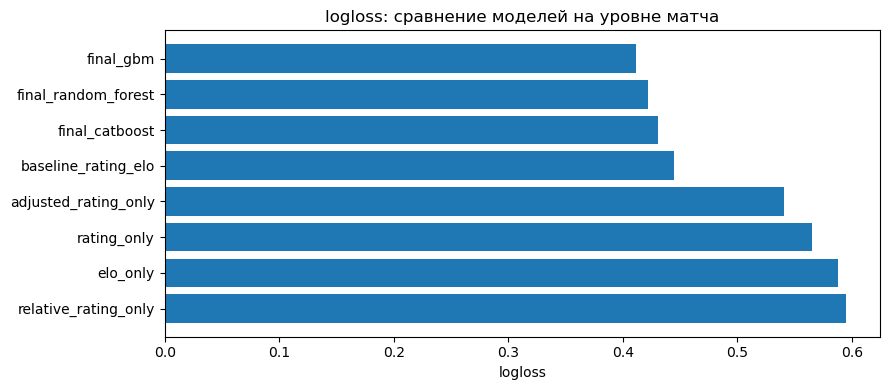

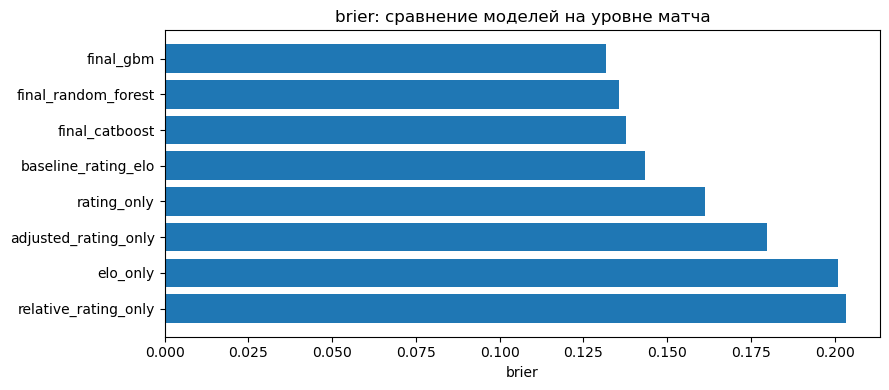

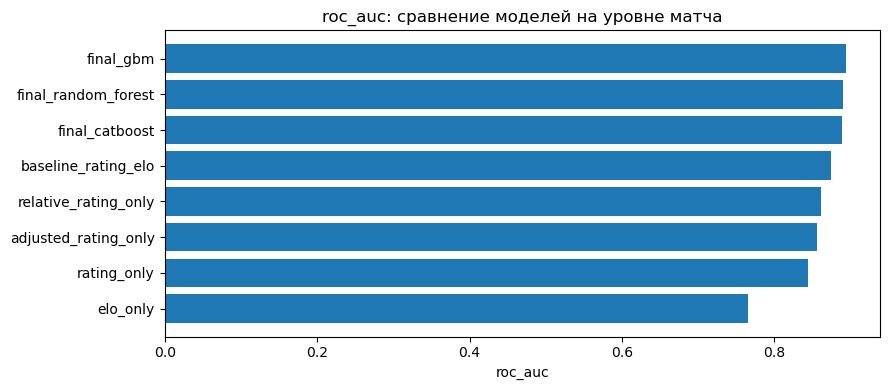

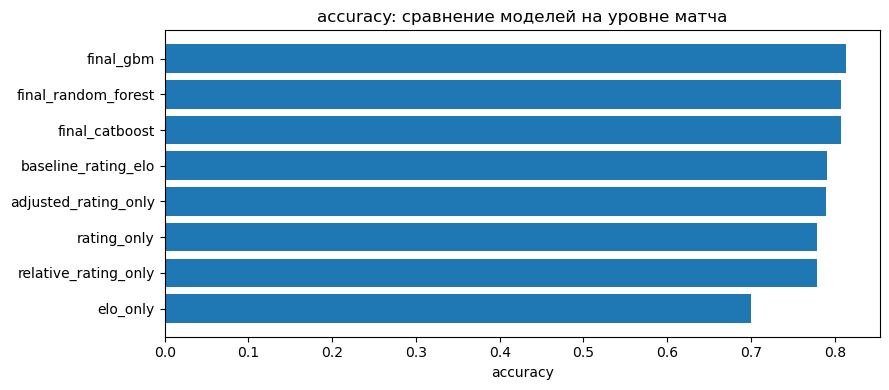

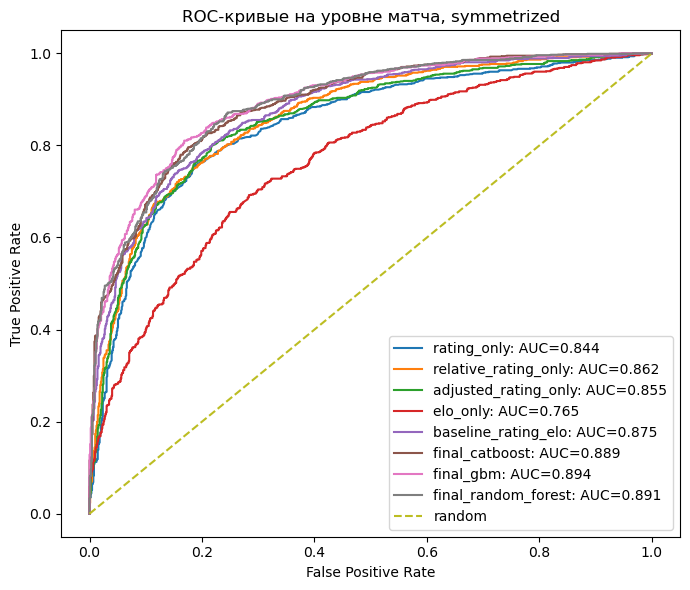

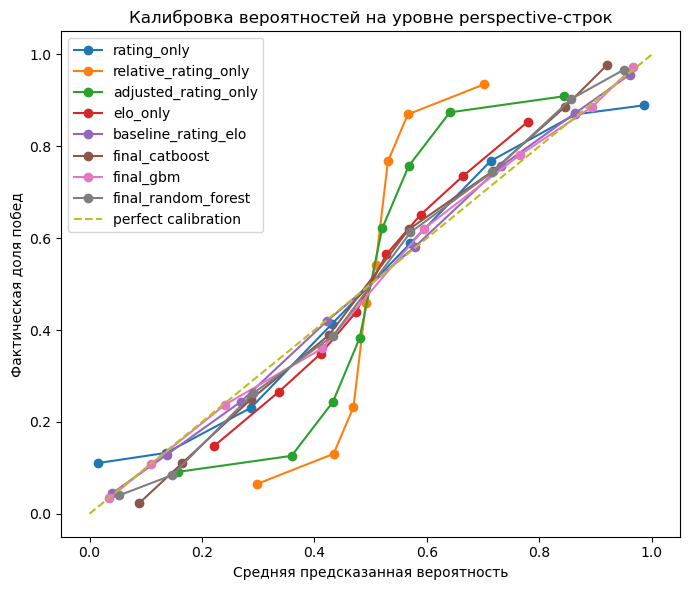

### Confusion matrix финальной модели

Прогноз: победит player1,0,1
Факт: победил player1,,
0,733,188
1,178,803


In [12]:
# display(Markdown("""
# ### Как читать метрики

# - **LogLoss** — главная метрика вероятностного прогноза. Чем меньше, тем лучше.
# - **Brier score** — средняя квадратичная ошибка вероятности. Чем меньше, тем лучше.
# - **ROC-AUC** — качество ранжирования победителей выше проигравших. 0.5 — случайно, 1.0 — идеально.
# - **Accuracy** — доля правильных ответов при пороге 50%. Простая, но менее информативная метрика.
# """))

display(metrics_table)

# Match-level / symmetrized comparison.
metric_plot_df = metrics_table[
    (metrics_table["level"] == "match")
    & (metrics_table["aggregation"] == "symmetrized")
].copy()

for metric in ["logloss", "brier", "roc_auc", "accuracy"]:
    plot_df = metric_plot_df.sort_values(metric, ascending=(metric in ["logloss", "brier"]))
    plt.figure(figsize=(9, 4))
    plt.barh(plot_df["model_name"], plot_df[metric])
    plt.title(f"{metric}: сравнение моделей на уровне матча")
    plt.xlabel(metric)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


def plot_match_level_roc(scored_test: pd.DataFrame, model_names: list[str]) -> None:
    plt.figure(figsize=(7, 6))

    for model_name in model_names:
        match_frame = match_level_frame(scored_test, model_name, mode="symmetrized")
        prob_col = f"p_player1_{model_name}_symmetrized"

        y = match_frame["winner_player1"].astype(int).to_numpy()
        p = pd.to_numeric(match_frame[prob_col], errors="coerce").to_numpy()

        mask = np.isfinite(p)
        if mask.sum() < 10 or len(np.unique(y[mask])) < 2:
            continue

        fpr, tpr, _ = roc_curve(y[mask], p[mask])
        auc = roc_auc_score(y[mask], p[mask])
        plt.plot(fpr, tpr, label=f"{model_name}: AUC={auc:.3f}")

    plt.plot([0, 1], [0, 1], linestyle="--", label="random")
    plt.title("ROC-кривые на уровне матча, symmetrized")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_calibration(scored_test: pd.DataFrame, model_names: list[str]) -> None:
    plt.figure(figsize=(7, 6))

    y = scored_test["win"].astype(int).to_numpy()

    for model_name in model_names:
        p = pd.to_numeric(scored_test[model_name], errors="coerce").to_numpy()
        mask = np.isfinite(p)

        if mask.sum() < 10 or len(np.unique(y[mask])) < 2:
            continue

        frac_pos, mean_pred = calibration_curve(y[mask], p[mask], n_bins=8, strategy="quantile")
        plt.plot(mean_pred, frac_pos, marker="o", label=model_name)

    plt.plot([0, 1], [0, 1], linestyle="--", label="perfect calibration")
    plt.title("Калибровка вероятностей на уровне perspective-строк")
    plt.xlabel("Средняя предсказанная вероятность")
    plt.ylabel("Фактическая доля побед")
    plt.legend()
    plt.tight_layout()
    plt.show()


plot_match_level_roc(scored_test, MODEL_DISPLAY_ORDER)
plot_calibration(scored_test, MODEL_DISPLAY_ORDER)

# Confusion matrix для финальной модели.
final_match_frame = match_level_frame(scored_test, "final_catboost", mode="symmetrized")
final_prob_col = "p_player1_final_catboost_symmetrized"
final_match_frame["pred_player1_win"] = (final_match_frame[final_prob_col] >= 0.5).astype(int)

display(Markdown("### Confusion matrix финальной модели"))
display(pd.crosstab(
    final_match_frame["winner_player1"],
    final_match_frame["pred_player1_win"],
    rownames=["Факт: победил player1"],
    colnames=["Прогноз: победит player1"],
))

### Как читать метрики качества модели

В задаче модель предсказывает не просто победителя, а вероятность победы. Поэтому важны не только правильные/неправильные ответы, но и то, насколько реалистичны сами вероятности.

#### LogLoss

`LogLoss` — основная метрика качества вероятностного прогноза.

Для бинарной классификации:

$$
LogLoss = -\frac{1}{N}\sum_{i=1}^{N}
\left[
y_i \ln(p_i) + (1-y_i)\ln(1-p_i)
\right]
$$

где:

- $y_i$ — фактический результат: `1`, если игрок выиграл, `0`, если проиграл;
- $p_i$ — предсказанная моделью вероятность победы;
- $N$ — число наблюдений.

Чем меньше `LogLoss`, тем лучше.  
Метрика сильно штрафует уверенные ошибочные прогнозы. Например, если модель дала вероятность победы `95%`, а игрок проиграл, штраф будет большим. Поэтому `LogLoss` хорошо подходит для задачи, где важна именно корректная вероятность, а не только выбор победителя.

#### Brier score

`Brier score` — средняя квадратичная ошибка вероятности:

$$
Brier = \frac{1}{N}\sum_{i=1}^{N}(p_i - y_i)^2
$$

где:

- $p_i$ — предсказанная вероятность победы;
- $y_i$ — фактический результат.

Чем меньше `Brier score`, тем лучше.  
Эта метрика показывает, насколько близко предсказанные вероятности находятся к фактическим исходам. В отличие от `LogLoss`, она мягче штрафует очень уверенные ошибки.

#### ROC-AUC

`ROC-AUC` показывает, насколько хорошо модель ранжирует победителей выше проигравших.

Простая интерпретация:

> ROC-AUC — это вероятность того, что модель даст более высокую вероятность победы реальному победителю, чем проигравшему.

Значения:

- `0.5` — качество как у случайного угадывания;
- `1.0` — идеальное ранжирование;
- чем выше, тем лучше.

Важно: `ROC-AUC` оценивает порядок прогнозов, но не проверяет, хорошо ли откалиброваны вероятности. Модель может хорошо ранжировать игроков, но при этом давать слишком завышенные или слишком заниженные вероятности.

#### Accuracy

`Accuracy` — доля правильных ответов при фиксированном пороге, обычно `50%`:

$$
Accuracy = \frac{TP + TN}{N}
$$

где:

- $TP$ — число правильно предсказанных побед;
- $TN$ — число правильно предсказанных поражений;
- $N$ — общее число наблюдений.

В нашем случае:

```text
если p >= 0.5 → прогнозируем победу
если p < 0.5 → прогнозируем поражение

## 11. Важность признаков финальной модели

### Важность признаков CatBoost: SHAP + PredictionValuesChange

,feature,prediction_values_change,mean_abs_shap,group,meaning
0,rel_diff_points_per_counting_tournament_pct_mi...,28.860734,0.507207,Скорректированный рейтинг,Относительная разница средних очков на зачётны...
1,diff_points_per_counting_tournament_pre_observ...,12.191002,0.280532,Скорректированный рейтинг,Разница средних рейтинговых очков на один зачё...
2,expected_win_prob_elo,12.586869,0.258587,ELO,Вероятность победы игрока по ELO до матча.
3,diff_rank_pre_observed_only,13.367037,0.247380,Официальный рейтинг,Разница рангов игрока и соперника до матча; сч...
4,elo_diff,8.596067,0.176059,ELO,Разница ELO игрока и соперника.
5,rel_diff_points_pct_min_pre_observed_only,3.474247,0.075464,Официальный рейтинг,Относительная разница рейтинговых очков в проц...
6,diff_points_pre_observed_only,1.967258,0.071125,Официальный рейтинг,Разница рейтинговых очков игрока и соперника д...
7,opponent_points_per_counting_tournament_pre,2.122236,0.035344,Скорректированный рейтинг,Средние рейтинговые очки соперника на один зач...
8,elo_pre,1.793330,0.032548,ELO,ELO игрока до матча.
9,opponent_points_pre,1.828675,0.030573,Официальный рейтинг,Рейтинговые очки соперника до матча.


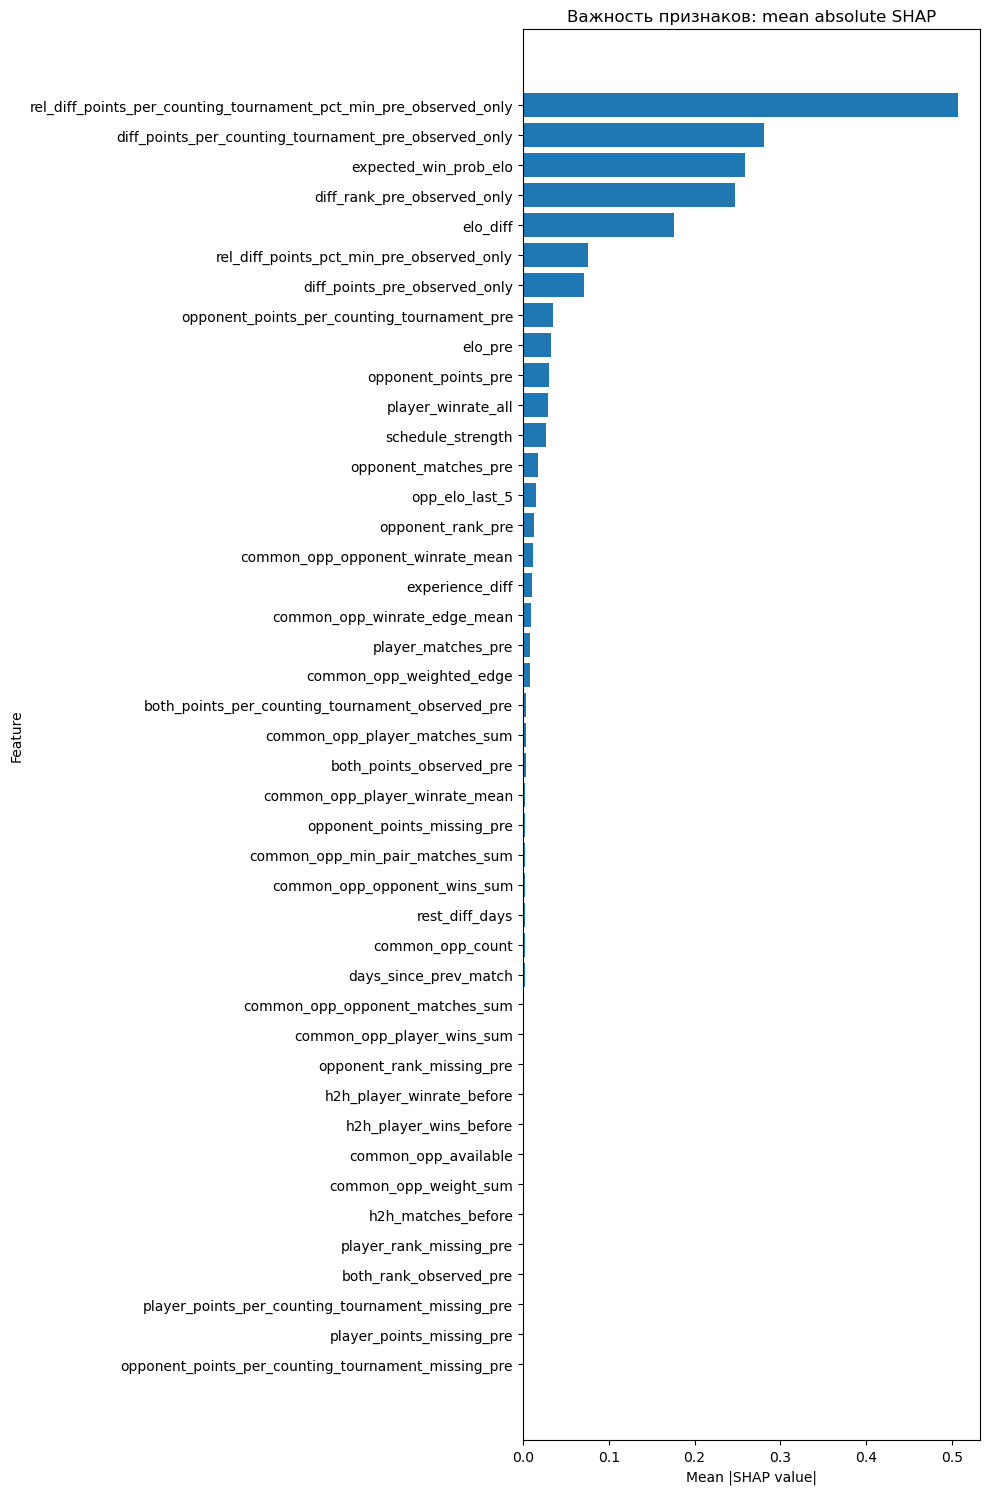

### Встроенная важность признаков для GBM и Random Forest

,model_name,feature,importance
0,final_gbm,rel_diff_points_per_counting_tournament_pct_mi...,0.712252
1,final_gbm,diff_points_per_counting_tournament_pre_observ...,0.053838
2,final_gbm,expected_win_prob_elo,0.041559
3,final_gbm,elo_diff,0.041225
4,final_gbm,rel_diff_points_pct_min_pre_observed_only,0.018658
5,final_gbm,opp_elo_last_5,0.012639
6,final_gbm,elo_pre,0.012287
7,final_gbm,opponent_rank_pre,0.010931
8,final_gbm,schedule_strength,0.010242
9,final_gbm,player_winrate_all,0.010241


In [13]:
def build_feature_importance_tables(
    model: CatBoostClassifier,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    max_shap_rows: int = 1000,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    pool_test = Pool(X_test, y_test)

    pvc = model.get_feature_importance(pool_test, type="PredictionValuesChange")
    pvc_df = (
        pd.DataFrame({
            "feature": X_test.columns,
            "prediction_values_change": pvc,
        })
        .sort_values("prediction_values_change", ascending=False)
        .reset_index(drop=True)
    )

    X_sample = X_test.sample(max_shap_rows, random_state=RANDOM_SEED) if len(X_test) > max_shap_rows else X_test.copy()
    pool_sample = Pool(X_sample)

    shap_values = model.get_feature_importance(pool_sample, type="ShapValues")
    mean_abs_shap = np.abs(shap_values[:, :-1]).mean(axis=0)

    shap_df = (
        pd.DataFrame({
            "feature": X_sample.columns,
            "mean_abs_shap": mean_abs_shap,
        })
        .sort_values("mean_abs_shap", ascending=False)
        .reset_index(drop=True)
    )

    return pvc_df, shap_df


feature_importance_pvc, feature_importance_shap = build_feature_importance_tables(
    model=final_model,
    X_test=X_test,
    y_test=y_test,
)

feature_importance_combined = (
    feature_importance_pvc
    .merge(feature_importance_shap, on="feature", how="outer")
    .merge(feature_catalog_table[["feature", "group", "meaning"]], on="feature", how="left")
    .sort_values("mean_abs_shap", ascending=False)
    .reset_index(drop=True)
)

display(Markdown("### Важность признаков CatBoost: SHAP + PredictionValuesChange"))
display(feature_importance_combined)

plot_df = feature_importance_combined.sort_values("mean_abs_shap", ascending=True)
plt.figure(figsize=(10, max(5, 0.35 * len(plot_df))))
plt.barh(plot_df["feature"], plot_df["mean_abs_shap"])
plt.title("Важность признаков: mean absolute SHAP")
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

def sklearn_pipeline_feature_importance(model: Pipeline, model_name: str, feature_names: list[str]) -> pd.DataFrame:
    """
    Достает feature_importances_ из sklearn tree-based моделей внутри Pipeline.
    Для GBM и Random Forest это не SHAP, а встроенная impurity-based важность.
    """
    fitted_model = model.named_steps.get("model")
    importances = getattr(fitted_model, "feature_importances_", None)

    if importances is None:
        return pd.DataFrame(columns=["model_name", "feature", "importance"])

    return (
        pd.DataFrame({
            "model_name": model_name,
            "feature": feature_names,
            "importance": importances,
        })
        .sort_values("importance", ascending=False)
        .reset_index(drop=True)
    )


sklearn_feature_importance_table = pd.concat(
    [
        sklearn_pipeline_feature_importance(final_gbm_model, "final_gbm", features),
        sklearn_pipeline_feature_importance(final_random_forest_model, "final_random_forest", features),
    ],
    ignore_index=True,
)

display(Markdown("### Встроенная важность признаков для GBM и Random Forest"))
display(sklearn_feature_importance_table.head(30))

## 12. Прогноз по двум игрокам

In [14]:
def build_player_directory(long_feat: pd.DataFrame) -> pd.DataFrame:
    directory = long_feat[["player_id", "player_name", "match_date"]].dropna(subset=["player_id"]).copy()
    directory["player_id"] = directory["player_id"].astype(str)
    directory["player_name_norm"] = directory["player_name"].apply(normalize_player_name)
    return directory.sort_values(["player_name_norm", "match_date"])


def resolve_player_id_by_name(long_feat: pd.DataFrame, player_name: str) -> dict:
    directory = build_player_directory(long_feat)
    name_norm = normalize_player_name(player_name)

    exact = directory[directory["player_name_norm"] == name_norm].copy()
    if not exact.empty:
        latest = exact.sort_values("match_date").iloc[-1]
        return {
            "found": True,
            "player_id": str(latest["player_id"]),
            "player_name": latest["player_name"],
            "candidates": exact[["player_id", "player_name", "match_date"]].drop_duplicates().tail(10),
        }

    partial = directory[directory["player_name_norm"].str.contains(name_norm, na=False, regex=False)].copy()
    if not partial.empty:
        latest = partial.sort_values("match_date").iloc[-1]
        return {
            "found": True,
            "player_id": str(latest["player_id"]),
            "player_name": latest["player_name"],
            "candidates": partial[["player_id", "player_name", "match_date"]].drop_duplicates().tail(10),
        }

    return {
        "found": False,
        "player_id": None,
        "player_name": None,
        "candidates": pd.DataFrame(columns=["player_id", "player_name", "match_date"]),
    }


def compute_elo_state_until(long_feat: pd.DataFrame, prediction_date: pd.Timestamp) -> dict[str, float]:
    match_base = build_match_level_base(long_feat)
    match_base = match_base[match_base["match_date"] < prediction_date].copy()

    elo_state = {}
    last_match_date = {}

    for match in match_base.itertuples(index=False):
        player1_id = str(match.player1_id)
        player2_id = str(match.player2_id)
        match_date = pd.Timestamp(match.match_date)

        rating1 = float(elo_state.get(player1_id, ELO_BASE_RATING))
        rating2 = float(elo_state.get(player2_id, ELO_BASE_RATING))
        expected_player1 = 1.0 / (1.0 + 10.0 ** ((rating2 - rating1) / 400.0))

        games_diff = getattr(match, "games_diff", np.nan)
        margin_multiplier = (
            1.0
            if pd.isna(games_diff)
            else 1.0 + ELO_MARGIN_COEF * np.log1p(abs(float(games_diff)))
        )

        def recency_weight(player_id: str) -> float:
            prev_date = last_match_date.get(player_id)
            if prev_date is None:
                return 1.0
            days = max((match_date - prev_date).days, 0)
            return 1.0 + (1.0 - np.exp(-days / ELO_RECENCY_HALF_LIFE_DAYS))

        winner_player1 = float(match.winner_player1)
        winner_player2 = 1.0 - winner_player1

        k1 = ELO_K * margin_multiplier * recency_weight(player1_id)
        k2 = ELO_K * margin_multiplier * recency_weight(player2_id)

        elo_state[player1_id] = rating1 + k1 * (winner_player1 - expected_player1)
        elo_state[player2_id] = rating2 + k2 * (winner_player2 - (1.0 - expected_player1))

        last_match_date[player1_id] = match_date
        last_match_date[player2_id] = match_date

    return elo_state


def player_history_rows(long_feat: pd.DataFrame, player_id: str, prediction_date: pd.Timestamp) -> pd.DataFrame:
    return (
        long_feat[
            (long_feat["player_id"].astype(str) == str(player_id))
            & (long_feat["match_date"] < prediction_date)
        ]
        .sort_values(["match_date", "match_id"])
        .copy()
    )


def get_last_player_snapshot(long_feat: pd.DataFrame, player_id: str, prediction_date: pd.Timestamp) -> pd.Series | None:
    history = player_history_rows(long_feat, player_id, prediction_date)
    if history.empty:
        return None
    return history.iloc[-1]


def h2h_stats_until(long_feat: pd.DataFrame, player_id: str, opponent_id: str, prediction_date: pd.Timestamp) -> dict:
    history = (
        long_feat[
            (long_feat["player_id"].astype(str) == str(player_id))
            & (long_feat["opponent_id"].astype(str) == str(opponent_id))
            & (long_feat["match_date"] < prediction_date)
        ]
        .sort_values(["match_date", "match_id"])
        .copy()
    )

    n_matches = int(history["match_id"].nunique()) if not history.empty else 0
    wins = int(history.drop_duplicates("match_id")["win"].sum()) if n_matches > 0 else 0

    return {
        "h2h_matches_before": n_matches,
        "h2h_player_wins_before": wins,
        "h2h_player_winrate_before": wins / n_matches if n_matches > 0 else np.nan,
    }


def build_common_opponent_stats_until(long_feat: pd.DataFrame, prediction_date: pd.Timestamp) -> dict:
    match_base = build_match_level_base(long_feat)
    match_base = match_base[match_base["match_date"] < prediction_date].copy()

    stats_by_player = defaultdict(dict)

    def update_stats(player_id: str, opponent_id: str, win: int, match_date: pd.Timestamp) -> None:
        current = stats_by_player[player_id].get(opponent_id)
        if current is None:
            current = {"n": 0, "wins": 0, "last_date": pd.Timestamp(match_date)}
        current["n"] = int(current["n"]) + 1
        current["wins"] = int(current["wins"]) + int(win)
        current["last_date"] = pd.Timestamp(match_date)
        stats_by_player[player_id][opponent_id] = current

    for match in match_base.itertuples(index=False):
        player1_id = str(match.player1_id)
        player2_id = str(match.player2_id)
        player1_win = int(match.winner_player1)
        match_date = pd.Timestamp(match.match_date)

        update_stats(player1_id, player2_id, player1_win, match_date)
        update_stats(player2_id, player1_id, 1 - player1_win, match_date)

    return stats_by_player


def build_common_opponent_prediction_features(
    long_feat: pd.DataFrame,
    player_a_id: str,
    player_b_id: str,
    prediction_date: pd.Timestamp,
) -> pd.DataFrame:
    stats_by_player = build_common_opponent_stats_until(long_feat, prediction_date)

    rows = [
        common_opponent_features_for_pair(stats_by_player, player_a_id, player_b_id, -1, "player1", prediction_date),
        common_opponent_features_for_pair(stats_by_player, player_b_id, player_a_id, -1, "player2", prediction_date),
    ]
    return pd.DataFrame(rows).drop(columns=["match_id"], errors="ignore")


def build_single_prediction_row(
    long_feat: pd.DataFrame,
    player_id: str,
    opponent_id: str,
    prediction_date: pd.Timestamp,
    perspective: str,
    context: dict,
    elo_state: dict[str, float],
) -> dict:
    player_last = get_last_player_snapshot(long_feat, player_id, prediction_date)
    opponent_last = get_last_player_snapshot(long_feat, opponent_id, prediction_date)

    player_history = player_history_rows(long_feat, player_id, prediction_date)
    opponent_history = player_history_rows(long_feat, opponent_id, prediction_date)

    player_elo = float(elo_state.get(str(player_id), ELO_BASE_RATING))
    opponent_elo = float(elo_state.get(str(opponent_id), ELO_BASE_RATING))
    expected = 1.0 / (1.0 + 10.0 ** ((opponent_elo - player_elo) / 400.0))

    def from_last(last_row: pd.Series | None, col: str, default=np.nan):
        if last_row is None or col not in long_feat.columns:
            return default
        return last_row.get(col, default)

    def days_since_last_match(history: pd.DataFrame) -> float:
        if history.empty:
            return np.nan
        return (prediction_date - pd.Timestamp(history["match_date"].iloc[-1])).days

    player_days_since = days_since_last_match(player_history)
    opponent_days_since = days_since_last_match(opponent_history)

    h2h = h2h_stats_until(long_feat, player_id, opponent_id, prediction_date)

    row = {
        "match_id": -1,
        "match_date": prediction_date,
        "perspective": perspective,
        "player_id": str(player_id),
        "opponent_id": str(opponent_id),
        "player_name": from_last(player_last, "player_name", str(player_id)),
        "opponent_name": from_last(opponent_last, "player_name", str(opponent_id)),
        "tournament_name": context.get("tournament_name", "__UNKNOWN_TOURNAMENT__"),
        "tournament_city": context.get("tournament_city", "__UNKNOWN_CITY__"),
        "tournament_age_category": context.get("tournament_age_category", "__UNKNOWN_AGE__"),
        "draw_type": context.get("draw_type", "__UNKNOWN_DRAW__"),

        "elo_pre": player_elo,
        "elo_opp_pre": opponent_elo,
        "elo_diff": player_elo - opponent_elo,
        "expected_win_prob_elo": expected,

        "player_rank_pre": from_last(player_last, "player_rank_pre"),
        "opponent_rank_pre": from_last(opponent_last, "player_rank_pre"),
        "player_points_pre": from_last(player_last, "player_points_pre"),
        "opponent_points_pre": from_last(opponent_last, "player_points_pre"),
        "player_rated_counting_tournaments_pre": from_last(player_last, "player_rated_counting_tournaments_pre"),
        "opponent_rated_counting_tournaments_pre": from_last(opponent_last, "player_rated_counting_tournaments_pre"),

        "player_matches_pre": len(player_history),
        "opponent_matches_pre": len(opponent_history),
        "experience_diff": len(player_history) - len(opponent_history),
        "player_winrate_all": float(player_history["win"].mean()) if not player_history.empty else np.nan,

        "days_since_prev_match": player_days_since,
        "rest_diff_days": player_days_since - opponent_days_since if pd.notna(player_days_since) and pd.notna(opponent_days_since) else np.nan,
        "schedule_strength": float(player_history["elo_opp_pre"].tail(SCHEDULE_STRENGTH_WINDOW).mean()) if not player_history.empty else player_elo,
        "opp_elo_last_5": float(player_history["elo_opp_pre"].tail(OPP_ELO_LAST_WINDOW).mean()) if not player_history.empty else opponent_elo,

        **h2h,
    }

    return row


def build_prediction_rows(
    long_feat: pd.DataFrame,
    player_a_id: str,
    player_b_id: str,
    prediction_date: pd.Timestamp,
    context: dict | None = None,
) -> pd.DataFrame:
    context = dict(context or {})
    prediction_date = pd.Timestamp(prediction_date)

    elo_state = compute_elo_state_until(long_feat, prediction_date)

    rows = [
        build_single_prediction_row(long_feat, player_a_id, player_b_id, prediction_date, "player1", context, elo_state),
        build_single_prediction_row(long_feat, player_b_id, player_a_id, prediction_date, "player2", context, elo_state),
    ]

    pred_df = pd.DataFrame(rows)
    pred_df = add_adjusted_rating_features(pred_df)
    pred_df = add_relative_diff_to_min_features(pred_df)
    pred_df = add_observed_only_features(pred_df)

    common_pred = build_common_opponent_prediction_features(long_feat, player_a_id, player_b_id, prediction_date)
    pred_df = pred_df.drop(columns=[col for col in COMMON_OPP_FEATURES if col in pred_df.columns], errors="ignore")
    pred_df = pred_df.merge(common_pred, on="perspective", how="left", validate="one_to_one")

    pred_df = fill_feature_nans(pred_df)

    for col in features:
        if col not in pred_df.columns:
            pred_df[col] = np.nan
        pred_df[col] = pd.to_numeric(pred_df[col], errors="coerce")

    return pred_df


def symmetrize_pair_probs(pred_rows: pd.DataFrame, prob_col: str = "p_model_raw") -> dict:
    if pred_rows.shape[0] != 2:
        raise ValueError("Expected exactly two rows: A vs B and B vs A")

    p_ab = float(pred_rows.iloc[0][prob_col])
    p_ba = float(pred_rows.iloc[1][prob_col])
    p_player1 = float(np.clip(0.5 * (p_ab + (1.0 - p_ba)), 0.0, 1.0))

    return {
        "p_player1_sym": p_player1,
        "p_player2_sym": 1.0 - p_player1,
        "p_ab": p_ab,
        "p_ba": p_ba,
        "symmetry_gap_abs": abs(p_ab - (1.0 - p_ba)),
    }


def build_h2h_detail(long_feat: pd.DataFrame, player_a_id: str, player_b_id: str) -> pd.DataFrame:
    mask = (
        ((long_feat["player_id"].astype(str) == str(player_a_id)) & (long_feat["opponent_id"].astype(str) == str(player_b_id)))
        | ((long_feat["player_id"].astype(str) == str(player_b_id)) & (long_feat["opponent_id"].astype(str) == str(player_a_id)))
    )

    cols = [
        "match_date",
        "player_name",
        "opponent_name",
        "win",
        "tournament_name",
        "tournament_city",
        "elo_pre",
        "elo_opp_pre",
        "elo_diff",
        "player_points_pre",
        "opponent_points_pre",
        "diff_points_pre_observed_only",
        "rel_diff_points_pct_min_pre_observed_only",
        "player_points_per_counting_tournament_pre",
        "opponent_points_per_counting_tournament_pre",
        "diff_points_per_counting_tournament_pre_observed_only",
        "rel_diff_points_per_counting_tournament_pct_min_pre_observed_only",
        "player_rank_pre",
        "opponent_rank_pre",
        "diff_rank_pre_observed_only",
    ]
    cols = [col for col in cols if col in long_feat.columns]

    return long_feat.loc[mask, cols].sort_values(["match_date", "player_name"]).reset_index(drop=True)


def shap_explain_prediction(model: CatBoostClassifier, X_pred: pd.DataFrame, top_n: int = 12) -> pd.DataFrame:
    pool = Pool(X_pred)
    shap_values = model.get_feature_importance(pool, type="ShapValues")

    rows = []
    for row_idx in range(X_pred.shape[0]):
        row_shap = shap_values[row_idx]
        row_df = (
            pd.DataFrame({
                "feature": X_pred.columns,
                "value": [X_pred.iloc[row_idx][col] for col in X_pred.columns],
                "shap_value": row_shap[:-1],
                "abs_shap_value": np.abs(row_shap[:-1]),
                "row_index": row_idx,
                "base_value_logit": row_shap[-1],
            })
            .sort_values("abs_shap_value", ascending=False)
            .head(top_n)
        )
        rows.append(row_df)

    return pd.concat(rows, ignore_index=True)


def explain_main_model_prediction(model, model_name: str, X_pred: pd.DataFrame, top_n: int = 12) -> pd.DataFrame:
    """
    Объясняет прогноз выбранной основной модели.

    Если лучшей моделью оказался CatBoost, используем локальные SHAP-факторы.
    Если лучшей моделью оказался sklearn GBM или Random Forest, используем
    встроенную глобальную важность признаков и показываем значения этих признаков
    в двух prediction-строках. Это не локальный SHAP, но дает понятное объяснение,
    какие признаки в выбранной модели в целом наиболее важны.
    """
    if isinstance(model, CatBoostClassifier):
        result = shap_explain_prediction(model, X_pred, top_n=top_n)
        result["model_name"] = model_name
        result["explanation_type"] = "local_catboost_shap"
        return result

    fitted_model = model.named_steps.get("model") if isinstance(model, Pipeline) else model
    importances = getattr(fitted_model, "feature_importances_", None)

    if importances is None:
        return pd.DataFrame(columns=[
            "model_name",
            "explanation_type",
            "row_index",
            "feature",
            "value",
            "global_importance",
        ])

    importance_df = (
        pd.DataFrame({
            "feature": X_pred.columns,
            "global_importance": importances,
        })
        .sort_values("global_importance", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    rows = []
    for row_idx in range(X_pred.shape[0]):
        row_df = importance_df.copy()
        row_df["row_index"] = row_idx
        row_df["value"] = [X_pred.iloc[row_idx][feature] for feature in row_df["feature"]]
        row_df["model_name"] = model_name
        row_df["explanation_type"] = "global_sklearn_feature_importance"
        rows.append(row_df)

    return pd.concat(rows, ignore_index=True)


def predict_match_by_names(
    long_feat: pd.DataFrame,
    model,
    player1_name: str,
    player2_name: str,
    prediction_date: str | pd.Timestamp,
    context: dict | None = None,
    model_name: str = "best_main_model",
) -> dict:
    prediction_date = pd.Timestamp(prediction_date)

    player1_info = resolve_player_id_by_name(long_feat, player1_name)
    player2_info = resolve_player_id_by_name(long_feat, player2_name)

    if not player1_info["found"] or not player2_info["found"]:
        return {
            "ok": False,
            "message": "Не удалось найти одного или обоих игроков.",
            "player1_lookup": player1_info,
            "player2_lookup": player2_info,
        }

    pred_rows = build_prediction_rows(
        long_feat=long_feat,
        player_a_id=player1_info["player_id"],
        player_b_id=player2_info["player_id"],
        prediction_date=prediction_date,
        context=context,
    )

    X_pred = pred_rows[features].copy()
    pred_rows["p_model_raw"] = model.predict_proba(X_pred)[:, 1]

    pair_summary = symmetrize_pair_probs(pred_rows, "p_model_raw")
    pred_rows["p_final_player1"] = pair_summary["p_player1_sym"]
    pred_rows["p_final_player2"] = pair_summary["p_player2_sym"]
    pred_rows["symmetry_gap_abs"] = pair_summary["symmetry_gap_abs"]

    explanation_df = explain_main_model_prediction(model, model_name, X_pred)
    h2h_detail = build_h2h_detail(long_feat, player1_info["player_id"], player2_info["player_id"])

    return {
        "ok": True,
        "prediction_rows": pred_rows,
        "p_player1_win": pair_summary["p_player1_sym"],
        "p_player2_win": pair_summary["p_player2_sym"],
        "h2h_detail": h2h_detail,
        "model_name": model_name,
        "explanation_table": explanation_df,
        "shap_table": explanation_df,  # backward compatibility для старого H2H-блока
        "player1_lookup": player1_info,
        "player2_lookup": player2_info,
    }

## 13. Расширенный H2H и общие соперники

In [15]:
def build_common_opponents_report(
    long_feat: pd.DataFrame,
    player_a_id: str,
    player_b_id: str,
    prediction_date: pd.Timestamp,
) -> tuple[pd.DataFrame, pd.DataFrame, dict]:
    prediction_date = pd.Timestamp(prediction_date)

    history = long_feat[long_feat["match_date"] < prediction_date].copy()
    history["player_id"] = history["player_id"].astype(str)
    history["opponent_id"] = history["opponent_id"].astype(str)

    a_history = history[history["player_id"] == str(player_a_id)].copy()
    b_history = history[history["player_id"] == str(player_b_id)].copy()

    common_opponents = sorted(set(a_history["opponent_id"]) & set(b_history["opponent_id"]))

    summary_rows = []
    detail_rows = []

    for common_id in common_opponents:
        a_vs = a_history[a_history["opponent_id"] == common_id].copy()
        b_vs = b_history[b_history["opponent_id"] == common_id].copy()

        if a_vs.empty or b_vs.empty:
            continue

        common_name_series = pd.concat([a_vs["opponent_name"], b_vs["opponent_name"]]).dropna().astype(str)
        common_name = common_name_series.iloc[-1] if not common_name_series.empty else common_id

        a_n = int(a_vs["match_id"].nunique())
        b_n = int(b_vs["match_id"].nunique())
        a_wins = int(a_vs["win"].sum())
        b_wins = int(b_vs["win"].sum())
        a_winrate = float(a_vs["win"].mean())
        b_winrate = float(b_vs["win"].mean())

        last_date = max(pd.Timestamp(a_vs["match_date"].max()), pd.Timestamp(b_vs["match_date"].max()))
        days_ago = max((prediction_date - last_date).days, 0)

        recency_weight = float(np.exp(-days_ago / COMMON_OPP_HALF_LIFE_DAYS))
        sample_weight = float(np.sqrt(min(a_n, b_n)))
        weight = recency_weight * sample_weight
        edge = a_winrate - b_winrate

        summary_rows.append({
            "common_opponent_id": common_id,
            "common_opponent_name": common_name,
            "player_a_matches_vs_common": a_n,
            "player_a_wins_vs_common": a_wins,
            "player_a_winrate_vs_common": a_winrate,
            "player_b_matches_vs_common": b_n,
            "player_b_wins_vs_common": b_wins,
            "player_b_winrate_vs_common": b_winrate,
            "winrate_edge_a_minus_b": edge,
            "days_ago": days_ago,
            "weight": weight,
            "weighted_edge": weight * edge,
        })

        keep_cols = [
            "match_date",
            "player_name",
            "opponent_name",
            "win",
            "tournament_name",
            "tournament_city",
            "elo_pre",
            "elo_opp_pre",
            "player_points_pre",
            "opponent_points_pre",
        ]
        keep_cols = [col for col in keep_cols if col in history.columns]

        for side, side_df in [("player_a", a_vs), ("player_b", b_vs)]:
            tmp = side_df[keep_cols].copy()
            tmp["side"] = side
            tmp["common_opponent_id"] = common_id
            tmp["common_opponent_name"] = common_name
            detail_rows.append(tmp)

    summary_df = pd.DataFrame(summary_rows)
    detail_df = pd.concat(detail_rows, ignore_index=True) if detail_rows else pd.DataFrame()

    if not summary_df.empty and summary_df["weight"].sum() > 0:
        weighted_edge = float(summary_df["weighted_edge"].sum() / summary_df["weight"].sum())
    else:
        weighted_edge = np.nan

    signal = {
        "n_common_opponents": int(len(summary_df)),
        "common_opponents_edge": weighted_edge,
        "common_opponents_pseudo_probability_a": (
            float(np.clip(0.5 + 0.5 * weighted_edge, 0.0, 1.0))
            if pd.notna(weighted_edge)
            else np.nan
        ),
        "direct_model_feature": True,
        "comment": "Результаты против общих соперников входят в финальную модель через common_opp_* признаки.",
    }

    if not summary_df.empty:
        summary_df = summary_df.sort_values(["weight", "days_ago"], ascending=[False, True]).reset_index(drop=True)

    if not detail_df.empty:
        detail_df = detail_df.sort_values(["common_opponent_name", "match_date", "side"]).reset_index(drop=True)

    return summary_df, detail_df, signal


def display_expanded_head_to_head(
    user_pred: dict,
    long_feat: pd.DataFrame,
    prediction_date: str | pd.Timestamp,
) -> dict | None:
    if not user_pred.get("ok", False):
        print("Прогноз не построен, H2H-блок недоступен.")
        return None

    player1_id = str(user_pred["player1_lookup"]["player_id"])
    player2_id = str(user_pred["player2_lookup"]["player_id"])
    prediction_date = pd.Timestamp(prediction_date)

    common_summary, common_detail, common_signal = build_common_opponents_report(
        long_feat=long_feat,
        player_a_id=player1_id,
        player_b_id=player2_id,
        prediction_date=prediction_date,
    )

    pred_rows = user_pred["prediction_rows"]
    player1_name = pred_rows.iloc[0]["player_name"]
    player2_name = pred_rows.iloc[1]["player_name"]

    lines = [
        f"### Расширенная интерпретация пары: {player1_name} vs {player2_name}",
        f"- Итоговая вероятность победы {player1_name}: **{user_pred['p_player1_win']:.1%}**.",
        f"- Итоговая вероятность победы {player2_name}: **{user_pred['p_player2_win']:.1%}**.",
        f"- Общих соперников до даты прогноза: **{common_signal['n_common_opponents']}**.",
    ]

    edge = common_signal["common_opponents_edge"]
    if pd.notna(edge):
        direction = (
            f"поддерживает {player1_name}"
            if edge > 0.05
            else f"поддерживает {player2_name}"
            if edge < -0.05
            else "не дает явного преимущества"
        )
        lines.append(f"- Weighted common-opponents edge = **{edge:+.3f}**; диагностически это {direction}.")
    else:
        lines.append("- Common-opponents edge не рассчитан: недостаточно общих соперников.")

    lines.append("- Common-opponents показатели входят в финальную модель через `common_opp_*` признаки.")

    display(Markdown("\n".join(lines)))

    display(Markdown("### 1. Личные встречи игроков"))
    h2h_detail = user_pred.get("h2h_detail", pd.DataFrame())
    display(h2h_detail if not h2h_detail.empty else pd.DataFrame({"message": ["Личных встреч до даты прогноза не найдено"]}))

    display(Markdown("### 2. Сводка по общим соперникам"))
    display(common_summary if not common_summary.empty else pd.DataFrame({"message": ["Общих соперников до даты прогноза не найдено"]}))

    display(Markdown("### 3. Детальные матчи с общими соперниками"))
    display(common_detail.head(100) if not common_detail.empty else pd.DataFrame({"message": ["Детальных матчей с общими соперниками нет"]}))

    display(Markdown("### 4. Факторы выбранной модели для строки A vs B"))
    explanation_df = user_pred.get("explanation_table", user_pred.get("shap_table", pd.DataFrame()))
    display(
        explanation_df[explanation_df["row_index"] == 0].head(12)
        if not explanation_df.empty
        else pd.DataFrame()
    )

    return {
        "common_summary": common_summary,
        "common_detail": common_detail,
        "common_signal": common_signal,
    }

## 14. Пример прогноза

In [16]:
USER_PLAYER_1 = "Смирнова М"
USER_PLAYER_2 = "Антипина"
USER_PRED_DATE = "2026-04-17"

USER_CONTEXT = {
    "tournament_name": "Тестовый турнир",
    "tournament_city": "Москва",
    "tournament_age_category": "до 17 лет",
    "draw_type": "Основной турнир",
}

user_pred = predict_match_by_names(
    long_feat=long_feat,
    model=best_main_model,
    model_name=best_main_model_name,
    player1_name=USER_PLAYER_1,
    player2_name=USER_PLAYER_2,
    prediction_date=USER_PRED_DATE,
    context=USER_CONTEXT,
)

print("OK:", user_pred["ok"])

if user_pred["ok"]:
    print("Модель для прогноза:", user_pred.get("model_name", best_main_model_name))
    print(f"Вероятность победы {USER_PLAYER_1}: {user_pred['p_player1_win']:.1%}")
    print(f"Вероятность победы {USER_PLAYER_2}: {user_pred['p_player2_win']:.1%}")

    display(Markdown("### prediction_rows"))
    display(user_pred["prediction_rows"])

    expanded_h2h_report = display_expanded_head_to_head(
        user_pred=user_pred,
        long_feat=long_feat,
        prediction_date=USER_PRED_DATE,
    )
else:
    print(user_pred["message"])
    display(user_pred["player1_lookup"]["candidates"])
    display(user_pred["player2_lookup"]["candidates"])

OK: True
Модель для прогноза: final_gbm
Вероятность победы Смирнова М: 22.5%
Вероятность победы Антипина: 77.5%


### prediction_rows

,match_id,match_date,perspective,player_id,opponent_id,player_name,opponent_name,tournament_name,tournament_city,tournament_age_category,...,common_opp_player_winrate_mean,common_opp_opponent_winrate_mean,common_opp_winrate_edge_mean,common_opp_weighted_edge,common_opp_weight_sum,common_opp_min_pair_matches_sum,p_model_raw,p_final_player1,p_final_player2,symmetry_gap_abs
0,-1,2026-04-17,player1,RNI:52288,RNI:48068,Смирнова М.В.,Антипина П.Д.,Тестовый турнир,Москва,до 17 лет,...,0.428571,0.428571,0.0,0.0,3.363407,7,0.211712,0.224963,0.775037,0.026501
1,-1,2026-04-17,player2,RNI:48068,RNI:52288,Антипина П.Д.,Смирнова М.В.,Тестовый турнир,Москва,до 17 лет,...,0.428571,0.428571,0.0,0.0,3.363407,7,0.761787,0.224963,0.775037,0.026501


### Расширенная интерпретация пары: Смирнова М.В. vs Антипина П.Д.
- Итоговая вероятность победы Смирнова М.В.: **22.5%**.
- Итоговая вероятность победы Антипина П.Д.: **77.5%**.
- Общих соперников до даты прогноза: **7**.
- Weighted common-opponents edge = **+0.000**; диагностически это не дает явного преимущества.
- Common-opponents показатели входят в финальную модель через `common_opp_*` признаки.

### 1. Личные встречи игроков

...

,common_opponent_id,common_opponent_name,player_a_matches_vs_common,player_a_wins_vs_common,player_a_winrate_vs_common,player_b_matches_vs_common,player_b_wins_vs_common,player_b_winrate_vs_common,winrate_edge_a_minus_b,days_ago,weight,weighted_edge
0,RNI:51940,Божинова К.Т.,1,1,1.0,1,1,1.0,0.0,25,0.870325,0.0
1,RNI:44980,Руданова В.С.,1,0,0.0,1,0,0.0,0.0,29,0.851197,0.0
2,RNI:47457,Утробина Р.В.,1,0,0.0,1,0,0.0,0.0,46,0.774486,0.0
3,RNI:45777,Миллер К.Д.,1,0,0.0,2,0,0.0,0.0,163,0.404317,0.0
4,RNI:45855,Осипова М.В.,1,1,1.0,1,1,1.0,0.0,335,0.155500,0.0
5,RNI:51067,Галаганова В.Д.,2,0,0.0,1,0,0.0,0.0,335,0.155500,0.0
6,RNI:45888,Уланова К.А.,1,1,1.0,1,1,1.0,0.0,339,0.152082,0.0


### 3. Детальные матчи с общими соперниками

,match_date,player_name,opponent_name,win,tournament_name,tournament_city,elo_pre,elo_opp_pre,player_points_pre,opponent_points_pre,side,common_opponent_id,common_opponent_name
0,2026-03-19,Смирнова М.В.,Божинова К.Т.,1,"Турнир ""Кубок Жемчужины Подмосковья""",Истра,1425.856532,1294.807399,321.0,405.0,player_a,RNI:51940,Божинова К.Т.
1,2026-03-23,Антипина П.Д.,Божинова К.Т.,1,Чемпионат Одинцовского городского округа Моско...,Одинцово,1517.380805,1286.878896,415.0,405.0,player_b,RNI:51940,Божинова К.Т.
2,2025-03-24,Смирнова М.В.,Галаганова В.Д.,0,Первенство городского округа Красногорск,Красногорск,1500.000000,1502.306932,207.0,440.0,player_a,RNI:51067,Галаганова В.Д.
3,2025-05-16,Антипина П.Д.,Галаганова В.Д.,0,Турнир города Москвы А Л Т - МАЙ 1,Москва,1523.663814,1541.768501,301.0,440.0,player_b,RNI:51067,Галаганова В.Д.
4,2025-05-17,Смирнова М.В.,Галаганова В.Д.,0,Турнир города Москвы А Л Т - МАЙ 1,Москва,1523.707113,1562.060044,207.0,440.0,player_a,RNI:51067,Галаганова В.Д.
5,2025-03-06,Антипина П.Д.,Миллер К.Д.,0,Первенство Одинцовского городского округа Моск...,Одинцово,1538.524109,1541.314317,301.0,594.0,player_b,RNI:45777,Миллер К.Д.
6,2025-07-30,Антипина П.Д.,Миллер К.Д.,0,Первенство Одинцовского городского округа Моск...,Одинцово,1571.436828,1661.601234,301.0,594.0,player_b,RNI:45777,Миллер К.Д.
7,2025-11-05,Смирнова М.В.,Миллер К.Д.,0,Первенство Одинцовского городского округа Моск...,Одинцово,1505.188186,1686.536852,207.0,594.0,player_a,RNI:45777,Миллер К.Д.
8,2025-05-16,Смирнова М.В.,Осипова М.В.,1,Турнир города Москвы А Л Т - МАЙ 1,Москва,1502.032363,1524.726161,207.0,239.0,player_a,RNI:45855,Осипова М.В.
9,2025-05-17,Антипина П.Д.,Осипова М.В.,1,Турнир города Москвы А Л Т - МАЙ 1,Москва,1503.589239,1502.822215,301.0,239.0,player_b,RNI:45855,Осипова М.В.


### 4. Факторы выбранной модели для строки A vs B

,feature,global_importance,row_index,value,model_name,explanation_type
0,rel_diff_points_per_counting_tournament_pct_mi...,0.712252,0,-29.283489,final_gbm,global_sklearn_feature_importance
1,diff_points_per_counting_tournament_pre_observ...,0.053838,0,-9.400000,final_gbm,global_sklearn_feature_importance
2,expected_win_prob_elo,0.041559,0,0.398706,final_gbm,global_sklearn_feature_importance
3,elo_diff,0.041225,0,-71.373998,final_gbm,global_sklearn_feature_importance
4,rel_diff_points_pct_min_pre_observed_only,0.018658,0,-29.283489,final_gbm,global_sklearn_feature_importance
5,opp_elo_last_5,0.012639,0,1506.393254,final_gbm,global_sklearn_feature_importance
6,elo_pre,0.012287,0,1442.937870,final_gbm,global_sklearn_feature_importance
7,opponent_rank_pre,0.010931,0,851.000000,final_gbm,global_sklearn_feature_importance
8,schedule_strength,0.010242,0,1563.967547,final_gbm,global_sklearn_feature_importance
9,player_winrate_all,0.010241,0,0.368421,final_gbm,global_sklearn_feature_importance


## 15. Сохранение результатов в отдельные папки


In [17]:
# ---------------------------------------------------------------------
# Сохранение результатов в структурированные папки
# ---------------------------------------------------------------------

# Все артефакты одного прогона сохраняются в отдельную папку рядом с исходным Excel.
# Так в корне не появляется россыпь csv-файлов, а результаты удобно проверять и архивировать.
run_timestamp = pd.Timestamp.now().strftime("%Y%m%d_%H%M%S")

RESULTS_ROOT = DATA_PATH.parent / "model_results"
RUN_DIR = RESULTS_ROOT / f"run_{run_timestamp}"

METRICS_DIR = RUN_DIR / "01_metrics"
PREDICTIONS_DIR = RUN_DIR / "02_predictions"
FEATURES_DIR = RUN_DIR / "03_features"
DIAGNOSTICS_DIR = RUN_DIR / "04_diagnostics"
MODEL_SELECTION_DIR = RUN_DIR / "05_model_selection"

for folder in [
    METRICS_DIR,
    PREDICTIONS_DIR,
    FEATURES_DIR,
    DIAGNOSTICS_DIR,
    MODEL_SELECTION_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

# 01_metrics
metrics_path = METRICS_DIR / "model_metrics.csv"
rating_scale_grid_path = METRICS_DIR / "rating_only_scale_grid.csv"
adjusted_rating_scale_grid_path = METRICS_DIR / "adjusted_rating_only_scale_grid.csv"
relative_rating_scale_grid_path = METRICS_DIR / "relative_rating_only_scale_grid.csv"

# 02_predictions
match_predictions_path = PREDICTIONS_DIR / "match_predictions.csv"

# 03_features
feature_list_path = FEATURES_DIR / "final_model_features.csv"
baseline_feature_list_path = FEATURES_DIR / "baseline_rating_elo_features.csv"
feature_catalog_path = FEATURES_DIR / "feature_catalog.csv"
feature_importance_path = FEATURES_DIR / "feature_importance.csv"

# 04_diagnostics
dataset_overview_path = DIAGNOSTICS_DIR / "dataset_overview.csv"

# 05_model_selection
catboost_mode_results_path = MODEL_SELECTION_DIR / "catboost_training_mode_selection.csv"
main_model_diagnostics_path = MODEL_SELECTION_DIR / "main_model_train_test_diagnostics.csv"
best_main_model_selection_path = MODEL_SELECTION_DIR / "best_main_model_selection.csv"
sklearn_feature_importance_path = FEATURES_DIR / "sklearn_tree_feature_importance.csv"

metrics_table.to_csv(metrics_path, index=False)
match_predictions_table.to_csv(match_predictions_path, index=False)

pd.DataFrame({"feature": features}).to_csv(feature_list_path, index=False)
pd.DataFrame({"feature": baseline_rating_elo_features}).to_csv(baseline_feature_list_path, index=False)
feature_catalog_table.to_csv(feature_catalog_path, index=False)
feature_importance_combined.to_csv(feature_importance_path, index=False)

overview_df.to_csv(dataset_overview_path, index=False)
catboost_mode_results.to_csv(catboost_mode_results_path, index=False)
main_model_diagnostics.to_csv(main_model_diagnostics_path, index=False)
best_main_model_selection_table.to_csv(best_main_model_selection_path, index=False)

if "sklearn_feature_importance_table" in globals() and isinstance(sklearn_feature_importance_table, pd.DataFrame):
    sklearn_feature_importance_table.to_csv(sklearn_feature_importance_path, index=False)

if isinstance(rating_scale_grid, pd.DataFrame) and not rating_scale_grid.empty:
    rating_scale_grid.to_csv(rating_scale_grid_path, index=False)

if isinstance(adjusted_rating_scale_grid, pd.DataFrame) and not adjusted_rating_scale_grid.empty:
    adjusted_rating_scale_grid.to_csv(adjusted_rating_scale_grid_path, index=False)

if isinstance(relative_rating_scale_grid, pd.DataFrame) and not relative_rating_scale_grid.empty:
    relative_rating_scale_grid.to_csv(relative_rating_scale_grid_path, index=False)

saved_files = [
    metrics_path,
    match_predictions_path,
    feature_list_path,
    baseline_feature_list_path,
    feature_catalog_path,
    feature_importance_path,
    dataset_overview_path,
    catboost_mode_results_path,
    main_model_diagnostics_path,
    best_main_model_selection_path,
]

if rating_scale_grid_path.exists():
    saved_files.append(rating_scale_grid_path)

if adjusted_rating_scale_grid_path.exists():
    saved_files.append(adjusted_rating_scale_grid_path)

if relative_rating_scale_grid_path.exists():
    saved_files.append(relative_rating_scale_grid_path)

if sklearn_feature_importance_path.exists():
    saved_files.append(sklearn_feature_importance_path)

saved_files_table = pd.DataFrame({
    "group": [path.parent.name for path in saved_files],
    "file": [path.name for path in saved_files],
    "path": [str(path) for path in saved_files],
})

print("Результаты сохранены в папку:")
print(RUN_DIR)

display(Markdown("### Сохраненные файлы"))
display(saved_files_table)

Результаты сохранены в папку:
assembled_predictor\model_results\run_20260430_133534


### Сохраненные файлы

,group,file,path
0,01_metrics,model_metrics.csv,assembled_predictor\model_results\run_20260430...
1,02_predictions,match_predictions.csv,assembled_predictor\model_results\run_20260430...
2,03_features,final_model_features.csv,assembled_predictor\model_results\run_20260430...
3,03_features,baseline_rating_elo_features.csv,assembled_predictor\model_results\run_20260430...
4,03_features,feature_catalog.csv,assembled_predictor\model_results\run_20260430...
5,03_features,feature_importance.csv,assembled_predictor\model_results\run_20260430...
6,04_diagnostics,dataset_overview.csv,assembled_predictor\model_results\run_20260430...
7,05_model_selection,catboost_training_mode_selection.csv,assembled_predictor\model_results\run_20260430...
8,05_model_selection,main_model_train_test_diagnostics.csv,assembled_predictor\model_results\run_20260430...
9,05_model_selection,best_main_model_selection.csv,assembled_predictor\model_results\run_20260430...
